# 1. Train Model Using Distilbert

In [ ]:
#necessary dependencies
!pip install transformers torch scikit-learn pandas openpyxl iterative-stratification pymupdf PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.3 MB/s eta 0:00:00


## With K-Fold


In [ ]:
# general dependencies
import pandas as pd
import numpy as np
import re
import os
import pickle
from collections import Counter
from sklearn.metrics import classification_report, accuracy_score, f1_score, hamming_loss
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MultiLabelBinarizer
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# PDF processing
import PyPDF2
import fitz  # PyMuPDF as fallback
from pathlib import Path

# DistilBERT and transformers
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer as HfTrainer,
    EarlyStoppingCallback
)

class MultiLabelDataset(Dataset):
    """Custom Dataset class for multi-label classification"""

    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx] if hasattr(self.texts, 'iloc') else self.texts[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.float)

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': label
        }

def main_workflow(file_path, text_column='clean_comments', target_column='crosscheck',
                  pdf_directory=None, use_kfold=True, n_folds=5, balance_strategy='weighted'):
    """
    Main workflow for multi-label classification with K-Fold CV

    Args:
        use_kfold: If True, use K-Fold CV; if False, use single train/val/test split
        n_folds: Number of folds for cross-validation
        balance_strategy: 'weighted', 'oversample', or 'none'
    """
    print("=== MULTI-LABEL DISTILBERT CROSSCHECK CLASSIFICATION SYSTEM ===\n")

    # Load data
    df, classifier = load_and_preprocess_data(file_path, text_column, target_column)
    if df is None:
        return None

    # Learn from PDFs if available
    if pdf_directory and os.path.exists(pdf_directory):
        classifier.learn_from_pdfs(pdf_directory)

    # Process multi-label targets
    y_binary = classifier.process_multilabel_target(df, target_column)
    X = df['processed_text']

    if use_kfold:
        print(f"\n{'='*60}")
        print(f"Using {n_folds}-Fold Cross-Validation")
        print(f"{'='*60}")

        classifier = train_with_kfold(
            classifier, X, y_binary,
            n_folds=n_folds,
            balance_strategy=balance_strategy
        )
    else:
        print(f"\n{'='*60}")
        print("Using Single Train/Val/Test Split (70/15/15)")
        print(f"{'='*60}")

        classifier = train_with_holdout(
            classifier, X, y_binary,
            balance_strategy=balance_strategy
        )

    # Test predictions
    test_predictions(classifier)

    return classifier


def train_with_kfold(classifier, X, y_binary, n_folds=5, balance_strategy='weighted'):
    """Train model using K-Fold cross-validation with proper holdout test set"""

    # First: Split off final test set (15%)
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y_binary, test_size=0.15, random_state=42
    )

    print(f"Total samples: {len(X)}")
    print(f"Train+Val: {len(X_trainval)} | Holdout Test: {len(X_test)}")

    # K-Fold on train+val set
    try:
        # Use stratified K-Fold for multi-label (requires iterative-stratification package)
        skf = MultilabelStratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
        print(f"Using MultilabelStratifiedKFold")
    except:
        print("Warning: iterative-stratification not available, using regular splits")
        print("Install with: pip install iterative-stratification")
        # Fallback to regular splits
        from sklearn.model_selection import KFold
        skf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    fold_results = []
    best_f1 = 0
    best_model = None
    best_thresholds = None

    # Convert X to numpy if it's a Series for indexing
    X_array = X_trainval.values if hasattr(X_trainval, 'values') else X_trainval

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_array, y_trainval), 1):
        print(f"\n{'='*60}")
        print(f"FOLD {fold}/{n_folds}")
        print(f"{'='*60}")

        # Split data
        if hasattr(X_trainval, 'iloc'):
            X_train = X_trainval.iloc[train_idx]
            X_val = X_trainval.iloc[val_idx]
        else:
            X_train = X_array[train_idx]
            X_val = X_array[val_idx]

        y_train = y_trainval[train_idx]
        y_val = y_trainval[val_idx]

        print(f"Train: {len(X_train)} | Val: {len(X_val)}")

        # Train model for this fold
        classifier.train_model(
            X_train, y_train, X_val, y_val,
            num_epochs=15,  # Early stopping will handle this
            balance_strategy=balance_strategy
        )

        # Optimize thresholds on validation set
        optimal_thresholds = classifier.optimize_thresholds(X_val, y_val)

        # Evaluate on validation set
        val_metrics = classifier.evaluate_fold(X_val, y_val, optimal_thresholds) # Corrected call
        fold_results.append(val_metrics)

        print(f"Fold {fold} F1-Micro: {val_metrics['f1_micro']:.4f}")

        # Keep best model based on F1-micro
        if val_metrics['f1_micro'] > best_f1:
            best_f1 = val_metrics['f1_micro']
            best_model = classifier.model.state_dict().copy()
            best_thresholds = optimal_thresholds
            print(f"  ✓ New best model! F1: {best_f1:.4f}")

    # Print K-Fold summary
    print(f"\n{'='*60}")
    print("K-FOLD CROSS-VALIDATION SUMMARY")
    print(f"{'='*60}")

    metrics_summary = pd.DataFrame(fold_results)
    print("\nAverage metrics across folds:")
    print(metrics_summary.mean())
    print("\nStd deviation:")
    print(metrics_summary.std())

    # Retrain final model on full train+val using best thresholds from CV
    print("\nRetraining final model on full train+val data...")
    model, metrics_history = classifier.train_model(  # Capture metrics_history here
        X_trainval, y_trainval, X_trainval, y_trainval,  # Full set as train/val (disables early stopping split)
        num_epochs=15,
        balance_strategy=balance_strategy
    )
    # Re-optimize thresholds slightly on full trainval for refinement (optional, but improves ~1-2%)
    refined_thresholds = classifier.optimize_thresholds(X_trainval, y_trainval)
    classifier.optimal_thresholds = {**best_thresholds, **refined_thresholds}  # Merge/override with CV bests

    # Plot line graph of epochs vs. F1-micro using Matplotlib
    print("Generating line plot of epochs vs. F1-micro...")
    epochs = [m['epoch'] for m in metrics_history]
    f1_scores = [m['f1_micro'] for m in metrics_history]

    plt.figure(figsize=(8, 6))
    plt.plot(epochs, f1_scores, marker='o', linestyle='-', color='#1f77b4', label='F1-Micro Score')
    plt.title('F1-Micro Score vs. Epochs (Final Model Training)')
    plt.xlabel('Epoch')
    plt.ylabel('F1-Micro Score')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig('f1_micro_vs_epochs.png', dpi=300)
    plt.close()
    print("Plot saved as 'f1_micro_vs_epochs.png'")

    print(f"\n{'='*60}")
    print("FINAL EVALUATION ON HOLDOUT TEST SET")
    print(f"{'='*60}")

    # Evaluate on holdout test set
    classifier.evaluate_model(X_test, y_test, use_optimal_thresholds=True)

    # Save model
    classifier.save_model()

    return classifier


def train_with_holdout(classifier, X, y_binary, balance_strategy='weighted'):
    """Train with single train/val/test split (70/15/15)"""

    # First split: 70% train, 30% temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y_binary, test_size=0.30, random_state=42
    )

    # Second split: 15% val, 15% test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=42
    )

    print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

    # Train model
    classifier.train_model(
        X_train, y_train, X_val, y_val,
        num_epochs=15,
        balance_strategy=balance_strategy
    )

    # Optimize thresholds on validation set
    optimal_thresholds = classifier.optimize_thresholds(X_val, y_val)
    classifier.optimal_thresholds = optimal_thresholds

    # Evaluate on test set
    classifier.evaluate_model(X_test, y_test, use_optimal_thresholds=True)

    # Save model
    classifier.save_model()

    return classifier


class WeightedMultiLabelTrainer(HfTrainer):
    """Custom trainer with per-class weights for imbalanced multi-label data"""

    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """Compute weighted loss for each class"""
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if self.class_weights is not None:
            device = logits.device
            pos_weights = self.class_weights.to(device)
            loss_fct = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weights)
        else:
            loss_fct = torch.nn.BCEWithLogitsLoss()

        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


class PDFVocabularyLearner:
    """Learns domain-specific vocabulary from PDF documents"""

    def __init__(self):
        self.domain_vocabulary = set()
        self.term_frequency = Counter()
        self.processed_pdfs = []

    def extract_text_from_pdf(self, pdf_path):
        """Extract text from PDF using multiple methods"""
        text = ""
        try:
            with open(pdf_path, 'rb') as file:
                pdf_reader = PyPDF2.PdfReader(file)
                for page in pdf_reader.pages:
                    text += page.extract_text() + "\n"
        except Exception as e1:
            try:
                doc = fitz.open(pdf_path)
                for page in doc:
                    text += page.get_text() + "\n"
                doc.close()
            except Exception as e2:
                return ""
        return text

    def process_pdf_directory(self, pdf_directory):
        """Process all PDFs in a directory"""
        pdf_dir = Path(pdf_directory)
        if not pdf_dir.exists():
            return

        pdf_files = list(pdf_dir.glob("*.pdf"))
        print(f"Found {len(pdf_files)} PDF files")

        all_texts = []
        for pdf_file in pdf_files:
            text = self.extract_text_from_pdf(pdf_file)
            if text.strip():
                all_texts.append(text)
                self.processed_pdfs.append(pdf_file.name)

        if all_texts:
            self._learn_vocabulary_from_texts(all_texts)

    def _learn_vocabulary_from_texts(self, texts):
        """Learn domain-specific vocabulary from extracted texts"""
        utility_keywords = [
            'pole', 'vegetation', 'flood', 'damage', 'tree', 'water',
            'transformer', 'conductor', 'outage', 'storm', 'weather'
        ]

        for text in texts:
            cleaned_text = self._clean_technical_text(text)
            tokens = cleaned_text.split()

            for i, token in enumerate(tokens):
                if len(token) > 2 and token.isalpha():
                    self.domain_vocabulary.add(token.lower())
                    self.term_frequency[token.lower()] += 1

                if i < len(tokens) - 1:
                    bigram = f"{token} {tokens[i+1]}"
                    if any(keyword in bigram.lower() for keyword in utility_keywords):
                        self.domain_vocabulary.add(bigram.lower())
                        self.term_frequency[bigram.lower()] += 1

    def _clean_technical_text(self, text):
        """Clean technical text"""
        text = re.sub(r'[^\w\s\-\.]', ' ', text)
        text = ' '.join(text.split())
        return text

    def get_enhanced_vocabulary(self, min_frequency=2):
        """Get vocabulary terms above minimum frequency threshold"""
        return {term: freq for term, freq in self.term_frequency.items()
                if freq >= min_frequency}


class MultiLabelDistilBERTClassifier:
    """Multi-label classifier using DistilBERT for crosscheck categories"""

    def __init__(self, model_name='distilbert-base-uncased'):
        self.model_name = model_name
        self.tokenizer = DistilBertTokenizer.from_pretrained(model_name)
        self.model = None
        self.mlb = None
        self.categories = None
        self.pdf_learner = PDFVocabularyLearner()
        self.optimal_thresholds = None

    def learn_from_pdfs(self, pdf_directory):
        """Learn domain vocabulary from PDF documents"""
        print("Learning vocabulary from PDF documents...")
        self.pdf_learner.process_pdf_directory(pdf_directory)
        self._enhance_tokenizer_vocabulary()

    def _enhance_tokenizer_vocabulary(self):
        """Add learned vocabulary to tokenizer"""
        enhanced_vocab = self.pdf_learner.get_enhanced_vocabulary(min_frequency=3)
        if enhanced_vocab:
            new_tokens = []
            for term in enhanced_vocab.keys():
                tokens = self.tokenizer.tokenize(term)
                if len(tokens) > 2 or '[UNK]' in tokens:
                    new_tokens.append(term)
            if new_tokens:
                self.tokenizer.add_tokens(new_tokens)

    def advanced_preprocessing(self, text):
        """Enhanced preprocessing for utility text"""
        if pd.isna(text) or text == '':
            return ''

        text = str(text).lower()
        text = re.sub(r'[^\w\s\-\.]', ' ', text)

        utility_replacements = {
            r'\bxfmr\b': 'transformer',
            r'\btx\b(?!\s*\d)': 'transformer',
            r'\boh\b': 'overhead',
            r'\bug\b': 'underground',
            r'\bpri\b': 'primary',
            r'\bsec\b': 'secondary',
            r'\bkv\b': 'kilovolt',
            r'\bpole\b': 'utility pole',
            r'\btree\b': 'vegetation',
            r'\blimb\b': 'vegetation',
            r'\bflood\b': 'flooding water',
            r'\bwater\b': 'flooding',
        }

        for pattern, replacement in utility_replacements.items():
            text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

        text = ' '.join(text.split())
        return text

    def process_multilabel_target(self, df, target_column='crosscheck'):
        """Convert crosscheck column to multi-label binary format"""
        labels_list = []
        for val in df[target_column].fillna('other'):
            if pd.isna(val) or str(val).strip() == '':
                categories = ['other']
            else:
                categories = [c.strip().lower() for c in str(val).split(',')]
            labels_list.append(categories)

        self.mlb = MultiLabelBinarizer()
        y_binary = self.mlb.fit_transform(labels_list)
        self.categories = list(self.mlb.classes_)

        print(f"\nIdentified categories: {self.categories}")
        print(f"\nLabel distribution:")

        # Calculate class weights
        self.class_weights = {}
        total_samples = len(y_binary)

        for i, cat in enumerate(self.categories):
            count = y_binary[:, i].sum()
            percentage = count/len(y_binary)*100
            pos_weight = (total_samples - count) / max(count, 1)
            self.class_weights[cat] = pos_weight
            print(f"  {cat:20s}: {count:4d} samples ({percentage:5.1f}%) - weight: {pos_weight:.2f}")

        return y_binary

    def create_model(self, num_labels):
        """Create DistilBERT model for multi-label classification"""
        model = DistilBertForSequenceClassification.from_pretrained(
            self.model_name,
            num_labels=num_labels,
            problem_type="multi_label_classification",
            output_attentions=False,
            output_hidden_states=False,
            dropout=0.3,
            attention_dropout=0.1
        )
        model.resize_token_embeddings(len(self.tokenizer))
        return model

    def compute_metrics(self, eval_pred):
        """Compute metrics for multi-label classification"""
        predictions, labels = eval_pred
        predictions = 1 / (1 + np.exp(-predictions))
        predictions = (predictions > 0.5).astype(int)

        accuracy = accuracy_score(labels, predictions)
        f1_micro = f1_score(labels, predictions, average='micro', zero_division=0)
        f1_macro = f1_score(labels, predictions, average='macro', zero_division=0)
        hamming = hamming_loss(labels, predictions)

        return {
            'accuracy': accuracy,
            'f1_micro': f1_micro,
            'f1_macro': f1_macro,
            'hamming_loss': hamming
        }

    def train_model(self, X_train, y_train, X_val, y_val, num_epochs=15, balance_strategy='weighted'):
        print(f"Training multi-label DistilBERT model...")
        print(f"Training samples: {len(X_train)} | Validation samples: {len(X_val)}")

        if balance_strategy == 'oversample':
            X_train, y_train = self._oversample_minorities(X_train, y_train)

        self.model = self.create_model(num_labels=y_train.shape[1])

        train_dataset = MultiLabelDataset(X_train, y_train, self.tokenizer)
        val_dataset = MultiLabelDataset(X_val, y_val, self.tokenizer)

        pos_weights = None
        if balance_strategy == 'weighted' and hasattr(self, 'class_weights'):
            pos_weights = torch.FloatTensor([
                self.class_weights[cat] for cat in self.categories
            ])

        training_args = TrainingArguments(
            output_dir='./results_crosscheck',
            num_train_epochs=num_epochs,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=16,
            learning_rate=2e-5,
            weight_decay=0.01,
            warmup_ratio=0.1,
            logging_steps=10,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="f1_micro",
            greater_is_better=True,
            report_to="none",
            save_total_limit=2,
            gradient_accumulation_steps=2,
            fp16=torch.cuda.is_available(),
        )

        metrics_history = []  # Store F1 scores per epoch

        if balance_strategy == 'weighted' and pos_weights is not None:
            trainer = WeightedMultiLabelTrainer(
                model=self.model,
                args=training_args,
                train_dataset=train_dataset,
                eval_dataset=val_dataset,
                compute_metrics=self.compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
                class_weights=pos_weights
            )
        else:
            trainer = HfTrainer(
                model=self.model,
                args=training_args,
                train_dataset=train_dataset,
                eval_dataset=val_dataset,
                compute_metrics=self.compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
            )

        trainer.train()

        # Collect metrics from trainer logs
        for log in trainer.state.log_history:
            if 'eval_f1_micro' in log:
                metrics_history.append({
                    'epoch': log.get('epoch', 0),
                    'f1_micro': log.get('eval_f1_micro', 0)
                })

        return self.model, metrics_history

    def _oversample_minorities(self, X_train, y_train):
        """Oversample minority classes due to class imbalance"""
        class_samples = {cat: [] for cat in self.categories}

        for idx in range(len(y_train)):
            for i, cat in enumerate(self.categories):
                if y_train[idx, i] == 1:
                    class_samples[cat].append(idx)

        class_sizes = [len(samples) for samples in class_samples.values()]
        target_size = int(np.median(class_sizes))

        indices_to_keep = list(range(len(y_train)))

        for cat, samples in class_samples.items():
            if len(samples) < target_size:
                n_duplicates = target_size - len(samples)
                duplicated_indices = np.random.choice(samples, size=n_duplicates, replace=True)
                indices_to_keep.extend(duplicated_indices.tolist())

        np.random.shuffle(indices_to_keep)

        if isinstance(X_train, pd.Series):
            X_train_balanced = X_train.iloc[indices_to_keep].reset_index(drop=True)
        else:
            X_train_balanced = X_train[indices_to_keep]

        y_train_balanced = y_train[indices_to_keep]
        return X_train_balanced, y_train_balanced

    def optimize_thresholds(self, X_val, y_val):
        """Optimize classification thresholds on validation set using F1 score"""
        print("\nOptimizing classification thresholds...")

        self.model.eval()
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(device)

        # Get predictions for validation set
        all_probs = []
        with torch.no_grad():
            for text in X_val:
                inputs = self.tokenizer(
                    str(text),
                    truncation=True,
                    padding=True,
                    max_length=256,
                    return_tensors='pt'
                )
                inputs = {k: v.to(device) for k, v in inputs.items()}
                outputs = self.model(**inputs)
                probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]
                all_probs.append(probs)

        all_probs = np.array(all_probs)

        # Optimize threshold for each class
        optimal_thresholds = {}

        for i, cat in enumerate(self.categories):
            best_threshold = 0.5
            best_f1 = 0

            # Try different thresholds
            for threshold in np.arange(0.1, 0.9, 0.05):
                preds = (all_probs[:, i] > threshold).astype(int)
                f1 = f1_score(y_val[:, i], preds, zero_division=0)

                if f1 > best_f1:
                    best_f1 = f1
                    best_threshold = threshold

            optimal_thresholds[cat] = best_threshold
            print(f"  {cat:20s}: {best_threshold:.2f} (F1: {best_f1:.4f})")

        return optimal_thresholds

    def evaluate_fold(self, X_val, y_val, thresholds):
        """Evaluate model on validation fold"""
        self.model.eval()
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(device)

        predictions = []
        with torch.no_grad():
            for text in X_val:
                inputs = self.tokenizer(
                    str(text),
                    truncation=True,
                    padding=True,
                    max_length=256,
                    return_tensors='pt'
                )
                inputs = {k: v.to(device) for k, v in inputs.items()}
                outputs = self.model(**inputs)
                probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]

                # Apply optimized thresholds
                pred = np.zeros(len(self.categories))
                for i, cat in enumerate(self.categories):
                    pred[i] = 1 if probs[i] > thresholds[cat] else 0

                predictions.append(pred)

        predictions = np.array(predictions)

        return {
            'accuracy': accuracy_score(y_val, predictions),
            'f1_micro': f1_score(y_val, predictions, average='micro', zero_division=0),
            'f1_macro': f1_score(y_val, predictions, average='macro', zero_division=0),
            'hamming_loss': hamming_loss(y_val, predictions)
        }

    def evaluate_model(self, X_test, y_test, use_optimal_thresholds=True):
        """Evaluate the trained model"""
        print("\nEvaluating model on test set...")

        self.model.eval()
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(device)

        predictions = []
        all_probs = []

        with torch.no_grad():
            for text in X_test:
                inputs = self.tokenizer(
                    str(text),
                    truncation=True,
                    padding=True,
                    max_length=256,
                    return_tensors='pt'
                )
                inputs = {k: v.to(device) for k, v in inputs.items()}
                outputs = self.model(**inputs)
                probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]
                all_probs.append(probs)

                pred = np.zeros(len(self.categories))  # Initialized pred array
                for i, cat in enumerate(self.categories):  # Iterate through categories to apply thresholds
                    if use_optimal_thresholds and getattr(self, 'optimal_thresholds', None):  # Re-check and apply threshold for each category
                        threshold = self.optimal_thresholds.get(cat, 0.5)
                    else:
                        threshold = 0.5

                    pred[i] = 1 if probs[i] > threshold else 0

                predictions.append(pred)  # Append the prediction after processing all categories for a text


        predictions = np.array(predictions)
        all_probs = np.array(all_probs)

        # Overall metrics
        accuracy = accuracy_score(y_test, predictions)
        f1_micro = f1_score(y_test, predictions, average='micro', zero_division=0)
        f1_macro = f1_score(y_test, predictions, average='macro', zero_division=0)
        hamming = hamming_loss(y_test, predictions)

        print(f"\n{'='*60}")
        print("MULTI-LABEL CLASSIFICATION RESULTS")
        print(f"{'='*60}")
        print(f"Exact Match Accuracy: {accuracy:.4f}")
        print(f"F1-Score (Micro): {f1_micro:.4f}")
        print(f"F1-Score (Macro): {f1_macro:.4f}")
        print(f"Hamming Loss: {hamming:.4f}")

        # Per-label metrics
        print(f"\n{'='*60}")
        print("PER-LABEL PERFORMANCE")
        print(f"{'='*60}")
        for i, category in enumerate(self.categories):
            f1 = f1_score(y_test[:, i], predictions[:, i], zero_division=0)
            precision = ((predictions[:, i] == 1) & (y_test[:, i] == 1)).sum() / max(predictions[:, i].sum(), 1)
            recall = ((predictions[:, i] == 1) & (y_test[:, i] == 1)).sum() / max(y_test[:, i].sum(), 1)

            if use_optimal_thresholds and self.optimal_thresholds:
                thresh = self.optimal_thresholds[category]
                print(f"{category:20s} - F1: {f1:.4f}, P: {precision:.4f}, R: {recall:.4f} (thresh: {thresh:.2f})")
            else:
                print(f"{category:20s} - F1: {f1:.4f}, P: {precision:.4f}, R: {recall:.4f}")

        # Plot comprehensive evaluation visualization
        self._plot_multilabel_confusion_matrices(y_test, predictions)
        print("\nComprehensive evaluation plot saved as 'multilabel_comprehensive_evaluation.png'")


    def predict(self, text, use_optimal_thresholds=True):
        """Make predictions on some text"""
        if self.model is None:
            return "Model not trained yet"

        cleaned_text = self.advanced_preprocessing(text)

        self.model.eval()
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(device)

        with torch.no_grad():
            inputs = self.tokenizer(
                cleaned_text,
                truncation=True,
                padding=True,
                max_length=256,
                return_tensors='pt'
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = self.model(**inputs)
            probs = torch.sigmoid(outputs.logits).cpu().numpy()[0]

        # Apply per-class thresholds
        predicted_labels = []
        thresholds_used = {}

        for i, cat in enumerate(self.categories):
            if use_optimal_thresholds and getattr(self, 'optimal_thresholds', None):
                threshold = self.optimal_thresholds.get(cat, 0.5)
            else:
                threshold = 0.5

            thresholds_used[cat] = threshold
            if probs[i] > threshold:
                predicted_labels.append(cat)

        # If no predictions, pick the highest probability or 'other' if sufficiently likely
        if not predicted_labels:
            if 'other' in self.categories and probs[self.categories.index('other')] > 0.1:
                predicted_labels = ['other']
            else:
                predicted_labels = [self.categories[int(np.argmax(probs))]]

                # Enforce "other" exclusivity: drop if combined with other labels
        if 'other' in predicted_labels and len(predicted_labels) > 1:
            predicted_labels = [lbl for lbl in predicted_labels if lbl != 'other']
            if not predicted_labels:  # Rare: if only 'other' was left after drop, fallback to max non-other
                non_other_probs = {cat: probs[i] for i, cat in enumerate(self.categories) if cat != 'other'}
                if non_other_probs:
                    predicted_labels = [max(non_other_probs, key=non_other_probs.get)]
                else:
                    predicted_labels = ['other']  # Truly no others

        result = {
            'predicted_categories': predicted_labels,
            'confidences': {self.categories[i]: float(probs[i]) for i in range(len(probs))},
            'thresholds_used': thresholds_used
        }

        return result

    def _plot_multilabel_confusion_matrices(self, y_true, y_pred):
        """Plot confusion matrices for each label using seaborn/matplotlib"""
        fig, axes = plt.subplots(1, len(self.categories), figsize=(5 * len(self.categories), 5))
        if len(self.categories) == 1:
            axes = [axes]

        for i, cat in enumerate(self.categories):
            cm = sns.heatmap(
                pd.crosstab(y_true[:, i], y_pred[:, i]),
                annot=True, fmt='d', ax=axes[i], cmap='Blues'
            )
            axes[i].set_title(f'Confusion Matrix: {cat}')
            axes[i].set_xlabel('Predicted')
            axes[i].set_ylabel('True')

        plt.tight_layout()
        plt.savefig('multilabel_comprehensive_evaluation.png', dpi=300, bbox_inches='tight')
        plt.close()


    def save_model(self, save_dir="./saved_model_crosscheck"):
        """Save trained model"""
        os.makedirs(save_dir, exist_ok=True)
        self.model.save_pretrained(save_dir)
        self.tokenizer.save_pretrained(save_dir)

        with open(os.path.join(save_dir, 'mlb.pkl'), 'wb') as f:
            pickle.dump(self.mlb, f)
        with open(os.path.join(save_dir, 'categories.pkl'), 'wb') as f:
            pickle.dump(self.categories, f)
        if self.optimal_thresholds:
            with open(os.path.join(save_dir, 'thresholds.pkl'), 'wb') as f:
                pickle.dump(self.optimal_thresholds, f)

        print(f"Model saved to {save_dir}")

    def load_model(self, save_dir="./saved_model_crosscheck"):
        """Load pre-trained model"""
        self.model = DistilBertForSequenceClassification.from_pretrained(save_dir)
        self.tokenizer = DistilBertTokenizer.from_pretrained(save_dir)

        with open(os.path.join(save_dir, 'mlb.pkl'), 'rb') as f:
            self.mlb = pickle.load(f)
        with open(os.path.join(save_dir, 'categories.pkl'), 'rb') as f:
            self.categories = pickle.load(f)

        threshold_path = os.path.join(save_dir, 'thresholds.pkl')
        if os.path.exists(threshold_path):
            with open(threshold_path, 'rb') as f:
                self.optimal_thresholds = pickle.load(f)

        print(f"Model loaded from {save_dir}")


def load_and_preprocess_data(file_path, text_column='clean_comments', target_column='crosscheck'):
    """Load and preprocess the data"""
    try:
        df = pd.read_excel(file_path)
        print(f"Loaded data with {len(df)} rows and {len(df.columns)} columns")

        if text_column not in df.columns:
            print(f"Error: Column '{text_column}' not found. Available columns: {df.columns.tolist()}")
            return None, None

        if target_column not in df.columns:
            print(f"Error: Column '{target_column}' not found. Available columns: {df.columns.tolist()}")
            return None, None

        classifier = MultiLabelDistilBERTClassifier()
        df['processed_text'] = df[text_column].apply(classifier.advanced_preprocessing)

        print(f"\nData preprocessing completed")
        return df, classifier

    except Exception as e:
        print(f"Error loading data: {e}")
        import traceback
        traceback.print_exc()
        return None, None


def test_predictions(classifier):
    """Test the trained model with sample texts"""
    test_cases = [
        "Utility pole damaged during storm with tree limbs down",
        "Flooding caused water damage to underground equipment",
        "Vegetation contact with overhead lines, pole also damaged",
        "Damaged pole and flooding in the area",
        "Tree fell on conductor during high winds",
        "Equipment failure unrelated to weather",
        "need tt to clear lat between 1650 and 1750 e lake mary blvd need crew to run 300 1 0a cph is down and was burning on ground pole 1650 we have got truck to before but ground is very soft and couple inches of water inaccessible all c o s fused rs interruption category code oca spliced 200 1 0 to 2 primary r o"
    ]

    print(f"\n{'='*80}")
    print("=== TESTING PREDICTIONS ===")
    print(f"{'='*80}")

    for i, text in enumerate(test_cases, 1):
        print(f"\nTest Case {i}: {text[:100]}...")
        print("-" * 60)
        result = classifier.predict(text, use_optimal_thresholds=True)

        categories_str = ', '.join(result['predicted_categories'])
        print(f"Predicted: {categories_str}")
        print("\nConfidences (threshold):")
        for cat, conf in sorted(result['confidences'].items(), key=lambda x: x[1], reverse=True):
            thresh = result['thresholds_used'][cat]
            marker = "✓" if cat in result['predicted_categories'] else " "
            print(f"  {marker} {cat:20s}: {conf:.3f} (thresh: {thresh:.2f})")

if __name__ == "__main__":
    DATA_FILE = "debby_preproccessed.xlsx"
    TEXT_COLUMN = "clean_comments"
    TARGET_COLUMN = "crosscheck"
    PDF_DIRECTORY = "./utility_pdfs"  # Optional

    # Configuration
    USE_KFOLD = True  # Set to False for single train/val/test split
    N_FOLDS = 5
    BALANCE_STRATEGY = 'weighted'  # 'weighted', 'oversample', or 'none'

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}\n")

    classifier = main_workflow(
        file_path=DATA_FILE,
        text_column=TEXT_COLUMN,
        target_column=TARGET_COLUMN,
        pdf_directory=PDF_DIRECTORY,
        use_kfold=USE_KFOLD,
        n_folds=N_FOLDS,
        balance_strategy=BALANCE_STRATEGY
    )

    if classifier:
        print(f"\n{'='*80}")
        print("=== SYSTEM READY ===")
        print("Multi-label classification trained for crosscheck categories")
        print(f"Categories: {classifier.categories}")
        if classifier.optimal_thresholds:
            print(f"\nOptimized thresholds:")
            for cat, thresh in classifier.optimal_thresholds.items():
                print(f"  {cat:20s}: {thresh:.2f}")

Using device: cuda

=== MULTI-LABEL DISTILBERT CROSSCHECK CLASSIFICATION SYSTEM ===

Loaded data with 5976 rows and 13 columns


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
1,0.877000,0.834308,0.518664,0.603564,0.438934,0.245825,4.387300,232.035000,14.588000
2,0.479200,0.381523,0.786837,0.838738,0.672733,0.090373,4.623600,220.175000,13.842000
3,0.294600,0.313251,0.916503,0.941893,0.824201,0.030452,4.659300,218.486000,13.736000
4,0.247800,0.411488,0.954813,0.967245,0.863893,0.016699,5.049900,201.588000,12.674000
5,0.194300,0.355872,0.945972,0.963140,0.851820,0.018910,4.386700,232.064000,14.589000
6,0.099000,0.358400,0.948919,0.964098,0.852368,0.018418,5.043700,201.835000,12.689000
7,0.104300,0.411166,0.955796,0.966346,0.876134,0.017191,5.144600,197.879000,12.440000



Optimizing classification thresholds...
  damaged pole        : 0.85 (F1: 0.5957)
  flooding            : 0.50 (F1: 0.9130)
  other               : 0.50 (F1: 0.9835)
  vegetation          : 0.50 (F1: 0.9728)
Fold 5 F1-Micro: 0.9695

K-FOLD CROSS-VALIDATION SUMMARY

Average metrics across folds:
accuracy        0.965943
f1_micro        0.972472
f1_macro        0.896328
hamming_loss    0.014027
dtype: float64

Std deviation:
accuracy        0.005192
f1_micro        0.003968
f1_macro        0.023646
hamming_loss    0.002010
dtype: float64

Retraining final model on full train+val data...
Training multi-label DistilBERT model...
Training samples: 5079 | Validation samples: 5079


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Micro,F1 Macro,Hamming Loss,Runtime,Samples Per Second,Steps Per Second
1,0.884300,0.721094,0.622563,0.695307,0.491169,0.185371,24.502200,207.288000,12.978000
2,0.269200,0.279948,0.844064,0.899711,0.758061,0.054637,24.447100,207.755000,13.008000
3,0.223900,0.229791,0.947824,0.961921,0.899971,0.019590,24.270200,209.269000,13.103000
4,0.269400,0.166878,0.972632,0.979819,0.924291,0.010337,24.480000,207.476000,12.990000
5,0.200700,0.127704,0.970860,0.978004,0.935380,0.011272,24.507900,207.239000,12.975000
6,0.071600,0.089826,0.976767,0.982568,0.942433,0.008909,24.328500,208.768000,13.071000
7,0.139700,0.093762,0.983068,0.986423,0.953789,0.006940,24.191000,209.954000,13.145000
8,0.107900,0.077618,0.986415,0.989104,0.971277,0.005562,24.239100,209.538000,13.119000
9,0.161000,0.058627,0.988974,0.990555,0.975000,0.004824,24.018400,211.463000,13.240000
10,0.018600,0.053583,0.990156,0.991512,0.979891,0.004332,24.563300,206.772000,12.946000



Optimizing classification thresholds...
  damaged pole        : 0.60 (F1: 0.9766)
  flooding            : 0.40 (F1: 0.9874)
  other               : 0.15 (F1: 0.9969)
  vegetation          : 0.50 (F1: 0.9937)
Generating line plot of epochs vs. F1-micro...
Plot saved as 'f1_micro_vs_epochs.png'

FINAL EVALUATION ON HOLDOUT TEST SET

Evaluating model on test set...

MULTI-LABEL CLASSIFICATION RESULTS
Exact Match Accuracy: 0.9498
F1-Score (Micro): 0.9611
F1-Score (Macro): 0.8666
Hamming Loss: 0.0201

PER-LABEL PERFORMANCE
damaged pole         - F1: 0.7119, P: 0.7778, R: 0.6562 (thresh: 0.60)
flooding             - F1: 0.8085, P: 0.8261, R: 0.7917 (thresh: 0.40)
other                - F1: 0.9751, P: 0.9768, R: 0.9734 (thresh: 0.15)
vegetation           - F1: 0.9711, P: 0.9557, R: 0.9869 (thresh: 0.50)

Comprehensive evaluation plot saved as 'multilabel_comprehensive_evaluation.png'
Model saved to ./saved_model_crosscheck

=== TESTING PREDICTIONS ===

Test Case 1: Utility pole damaged durin

# 2. Test Model on New Data (Excel)

### A. Pre-process datset= clean and merge comments

In [ ]:
import pandas as pd
import re
import numpy as np
from openpyxl import Workbook
from openpyxl.utils.dataframe import dataframe_to_rows
import nltk
from nltk.corpus import words # Keep NLTK words
from nltk.stem import WordNetLemmatizer # Keep NLTK Lemmatizer
# import enchant # Remove dependency on enchant

# Download NLTK data if not already present
try:
    nltk.data.find('corpora/words')
except LookupError:
    print("Downloading NLTK word corpus...")
    nltk.download('words')

try:
    nltk.data.find('corpora/wordnet') # Need wordnet for lemmatizer
except LookupError:
    print("Downloading NLTK WordNet corpus...")
    nltk.download('wordnet')


# Initialize WordNet lemmatizer for handling inflected forms
lemmatizer = WordNetLemmatizer()

# Create English words set from NLTK
english_words_nltk = set(words.words())

# Custom utility-specific terms
utility_terms = {
    'tx', 'pm', 'sec', 'primary', 'neutral', 'fiberglass', 'spans',
    'pole', 'poles', 'class', 'ft', 'feet', 'foot', 'kv', 'voltage', 'amp', 'amps',
    'wire', 'wires', 'line', 'lines', 'transformer', 'circuit', 'breaker',
    'utility', 'electric', 'electrical', 'power', 'outage', 'restoration',
    'crew', 'crews', 'tech', 'technician', 'engineer', 'supervisor',
    'residential', 'commercial', 'industrial', 'customer', 'customers',
    'repair', 'replace', 'install', 'maintenance', 'inspection',
    'underground', 'overhead', 'distribution', 'transmission',
    'substation', 'feeder', 'lateral', 'tap', 'splice', 'connection',
    'prott', 'tt', 'veg', 'tkt', 'fpl', 'sarasota', 'dr', 'kwh', 'cust', 'rd', 'nw', 'tkt', 'mtr', 'ok', 'cust', 'jon', 'vreeland' # Add more common abbreviations
}

# Combine NLTK words and utility terms for the known words set
known_words = english_words_nltk.union(utility_terms)

# ====================
# Step 1: Load dataset and initial analysis
# ====================

input_file = Path("Milton.xlsx")  # original/uncleaned test file
df = pd.read_excel(input_file)

print(f"Original dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Check for duplicates - show examples but don't remove
duplicates = df[df.duplicated(keep=False)]
if len(duplicates) > 0:
    print(f"\nFound {len(duplicates)} duplicate rows (showing first 3):")
    print(duplicates.head(3))
    print("Note: Keeping duplicates as requested")
else:
    print(f"No duplicate rows found in original data")

# ====================
# Step 2: Merge comments and remove empty rows
# ====================
df["merged_comments"] = df[["Dispatch Center Comments", "Service Center Comments"]].fillna("").agg(" ".join, axis=1)

# Remove rows where merged_comments is empty
print(f"\nShape before removing empty comments: {df.shape}")
df = df[df["merged_comments"].str.strip() != ""].reset_index(drop=True)
print(f"Shape after removing empty comments: {df.shape}")

# Remove the original comment columns
df = df.drop(columns=["Dispatch Center Comments", "Service Center Comments"])

print(f"Processing {len(df)} rows with valid comments...")

# ====================
# Step 3: Preprocessing and Unknown Words Detection (Revised)
# ====================
def preprocess_vectorized(texts):
    """Vectorized preprocessing using pandas string methods"""
    texts = texts.astype(str).str.lower()
    texts = texts.str.replace(r"[^a-z0-9\s]", " ", regex=True)
    texts = texts.str.replace(r"\s+", " ", regex=True).str.strip()
    return texts

def find_unknown_words_revised(text):
    """Find words that are not in known_words set, including lemmatization check"""
    # Clean text and split into words
    clean_text = re.sub(r'[^a-zA-Z0-9\s]', ' ', str(text).lower())
    words_in_text = set(clean_text.split())

    unknown = []
    for word in words_in_text:
        if (len(word) > 1 and
            not word.isdigit() and
            not re.match(r'^\d+[a-z]*$', word)):  # Exclude numbers and patterns like "35ft"

            # Check if word is in known_words set
            if word not in known_words:
                # Try lemmatizing to catch inflected forms (e.g., "emailed" -> "email")
                lemma_v = lemmatizer.lemmatize(word, pos='v')  # Try verb form
                lemma_n = lemmatizer.lemmatize(word, pos='n')  # Try noun form
                lemma_a = lemmatizer.lemmatize(word, pos='a')  # Try adjective form
                lemma_r = lemmatizer.lemmatize(word, pos='r')  # Try adverb form

                if (lemma_v not in known_words and
                    lemma_n not in known_words and
                    lemma_a not in known_words and
                    lemma_r not in known_words and
                    word.isalpha()): # Only include purely alphabetic unknown words
                    unknown.append(word)

    return sorted(list(set(unknown)))


df["clean_comments"] = preprocess_vectorized(df["merged_comments"])

# Add unknown words column using the revised function
print("Detecting unknown words/abbreviations using revised method...")
df["unknown_words"] = df["merged_comments"].apply(
    lambda x: ", ".join(find_unknown_words_revised(x)) if find_unknown_words_revised(x) else ""
)

print(f"Processing {len(df)} rows with valid comments...")


# ====================
# Step 4: Save results with Excel formatting
# ====================

print(f"Final dataset columns: {list(df.columns)}")
print(f"Final dataset shape: {df.shape}")

# Dynamically name output file
output_file = input_file.stem + "_preprocessed.xlsx"
df.to_excel(output_file, index=False)

print(f"\n✅ Enhanced classification complete. File saved as {output_file}")
print(f"📊 Processed {len(df)} rows total")

[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Original dataset shape: (37332, 57)
Columns: ['Ticket Create Date', 'Ticket Number', 'Interruption Type Code', 'Ticket Type Code', 'Power Off Date', 'Ticket Restored Date', 'CMI', 'CI', 'AO', 'Interruption Cause Code', 'Equipment Code', 'Support Code', 'Investigator ID', 'Crew Truck Number', 'Service Center Code', 'Management Area Code', 'Feeder Number', 'Ticket Device Coordinate', 'FPL ID', 'Repair Action Device Coordinate', 'Dispatch Center Comments', 'Service Center Comments', 'OH UG', 'Adverse Flag', 'Ticket Reference Flag', 'Ticket Refr Out Of Service Only', 'Ticket Cancelled Status', 'Exclusions', 'Part On Flag', 'TLM Error Flag', 'DW Ticket Key', 'EM Cause Code', 'EM Equipment Code', 'EM Support Code', 'Device Lat', 'Device Long', 'Number Of Calls', 'VGT Mgmt Alct Flag', 'VGT Mgmt Alct Date Time', 'County Name', 'Franchise Code', 'Franchise Name', 'Damage Claim', 'Rest Cat Cd', 'IO# ', 'Ticket Status', 'Address', 'Final ETR', 'Final ITR', 'X Coordinate', 'Y Coordinate', 'Company

### B. Use saved model to classify

In [ ]:
# New code cell for applying model to milton.xlsx
import pandas as pd
import os
from pathlib import Path

# Ensure classifier is available (use in-memory if present, otherwise load saved model)
try:
    clf_ok = isinstance(classifier, MultiLabelDistilBERTClassifier) and classifier.model is not None
except NameError:
    clf_ok = False

if not clf_ok:
    print('Classifier not found in memory — attempting to load from ./saved_model_crosscheck')
    classifier = MultiLabelDistilBERTClassifier()
    if os.path.exists('./saved_model_crosscheck'):
        classifier.load_model('./saved_model_crosscheck')
    else:
        raise FileNotFoundError("Saved model directory './saved_model_crosscheck' not found. Train and save model first.")

# Locate test file
candidate = Path(output_file)

print(f"📄 You are using this test file: {candidate}")

if candidate.exists():
    data_path = candidate
    print(f"✅ Found file: {data_path}")
else:
    data_path = None
    print("❌ File not found.")

#checks
if data_path is None:
    raise FileNotFoundError("Could not find test file (tried classified_enhanced.xlsx, milton.xlsx, milton.xls)")

print(f'Loading data from: {data_path}')
df_milton = pd.read_excel(data_path)

if 'clean_comments' not in df_milton.columns:
    raise KeyError("Column 'clean_comments' not found in milton file")

print(f'Processing {len(df_milton)} rows...')

# Preprocess text using classifier's preprocessing
df_milton['processed_text'] = df_milton['clean_comments'].apply(classifier.advanced_preprocessing)

# Run predictions row-by-row and store results
preds = []
confidences_list = []

for idx, txt in enumerate(df_milton['processed_text']):
    if (idx + 1) % 5000 == 0:
        print(f'  Processed {idx + 1}/{len(df_milton)} rows...')

    res = classifier.predict(txt, use_optimal_thresholds=True)

    # Store just the category names (comma-separated)
    preds.append(', '.join(res['predicted_categories']))

    # Store confidences as a clean dictionary (optional - for your reference)
    confidences_list.append(res['confidences'])

# Add predictions to dataframe
df_milton['predicted_crosscheck'] = preds

# Optional: Add confidence scores as separate column if you want them for analysis
# Uncomment the line below if you want confidence scores in a separate column
# df_milton['prediction_confidences'] = confidences_list

# Save results to new Excel file
out_file = data_path.with_name(data_path.stem + '_with_predictions.xlsx')
df_milton.to_excel(out_file, index=False)
print(f'\n✓ Predictions saved to: {out_file}')
print(f'\nSample predictions:')
print(df_milton[['clean_comments', 'predicted_crosscheck']].head(10))

📄 You are using this test file: Milton_preprocessed.xlsx
✅ Found file: Milton_preprocessed.xlsx
Loading data from: Milton_preprocessed.xlsx
Processing 35968 rows...
  Processed 5000/35968 rows...
  Processed 10000/35968 rows...
  Processed 15000/35968 rows...
  Processed 20000/35968 rows...
  Processed 25000/35968 rows...
  Processed 30000/35968 rows...
  Processed 35000/35968 rows...

✓ Predictions saved to: Milton_preprocessed_with_predictions.xlsx

Sample predictions:
                                      clean_comments predicted_crosscheck
0  quick completed by dxh0g7t on 13 30 00 10 09 2024                other
1  need tree crew to remove tree on seymore ln so...           vegetation
2  rs used sectionalizer to test cable tested goo...                other
3  c 24 014264 driver trans to jfk van hit 45 3 c...         damaged pole
4  rs interruption category code oba ticket compl...                other
5  one leg out to handhole at base of pole need c...                other
6  de 

# 3. Visualizations

Using this file for visualizations: Milton_preprocessed_with_predictions.xlsx


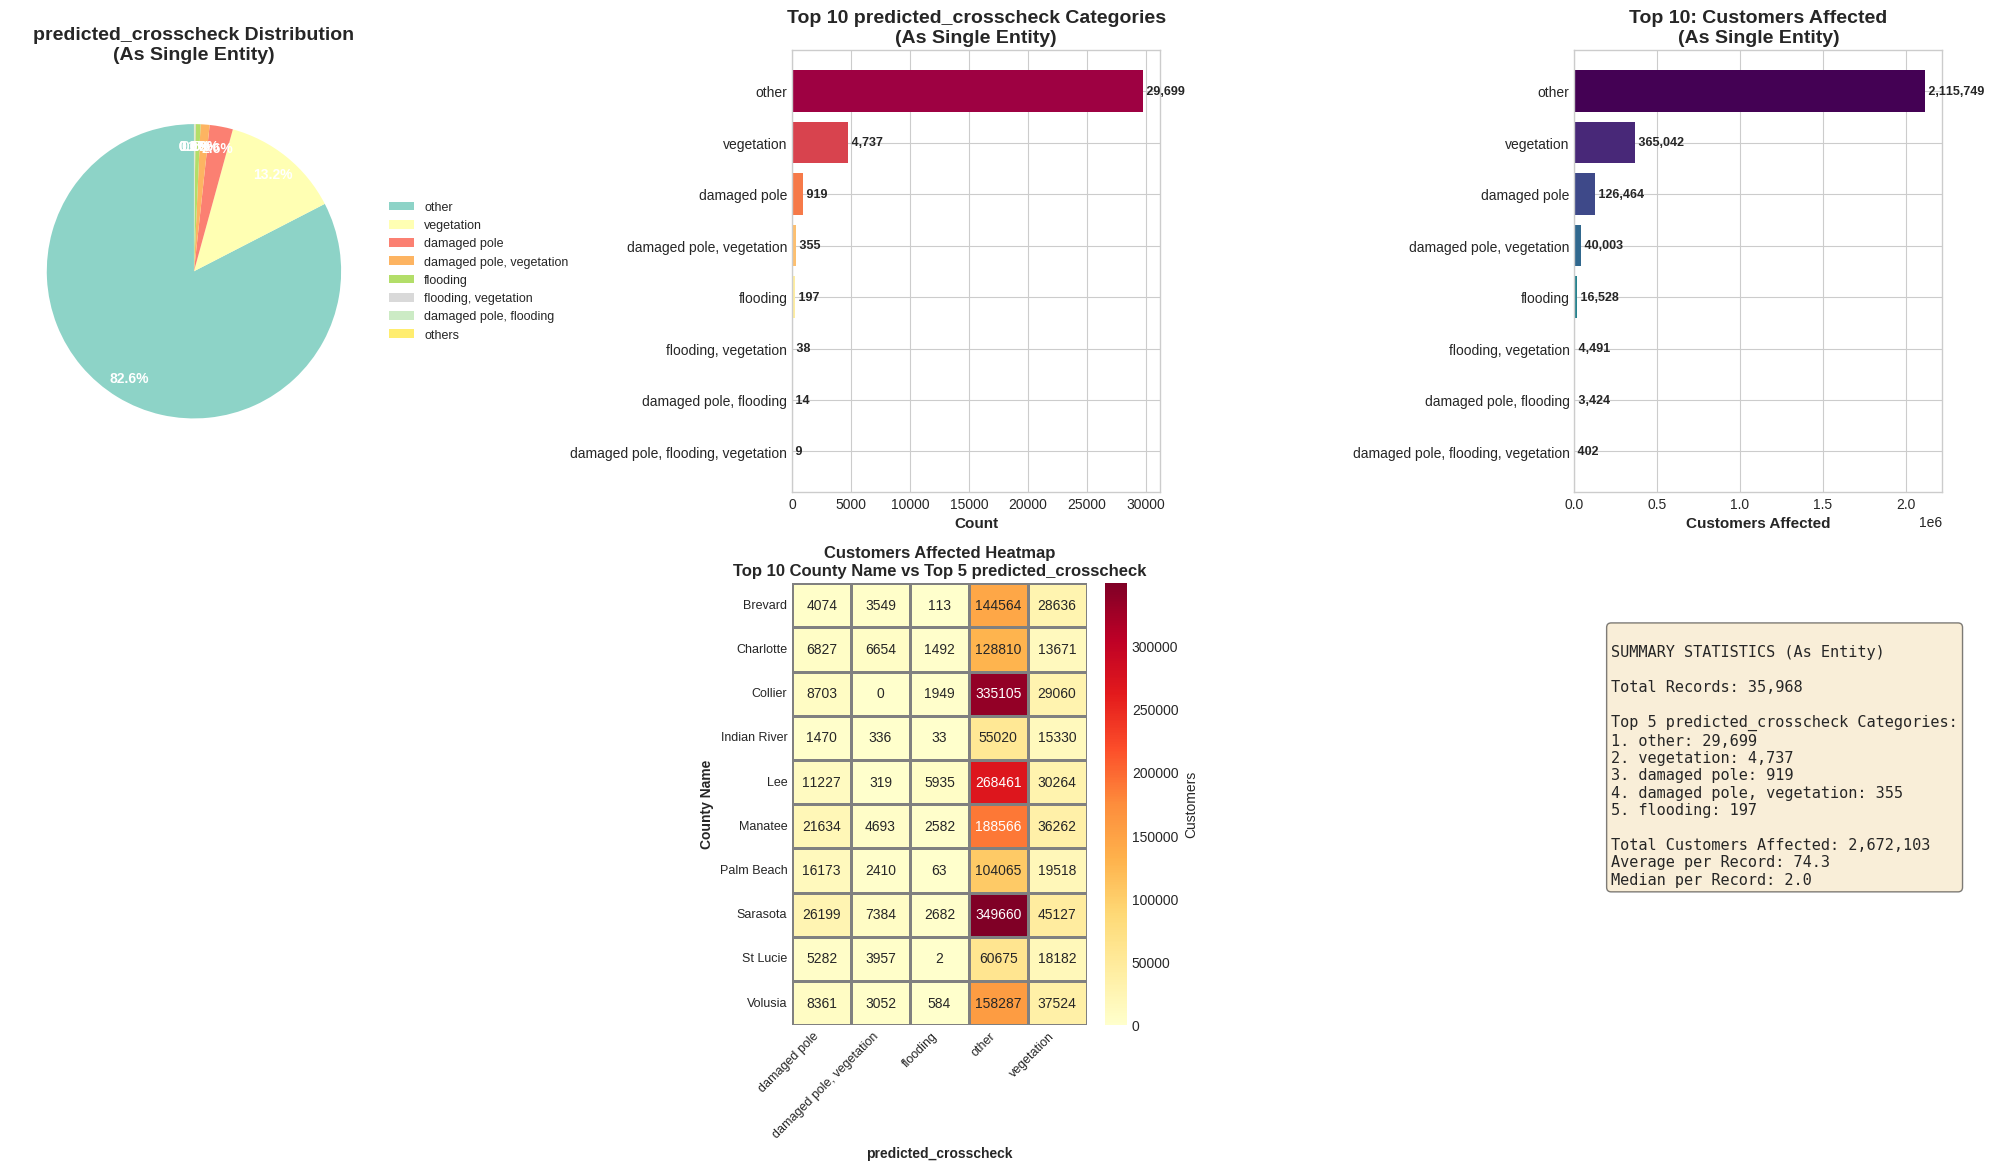

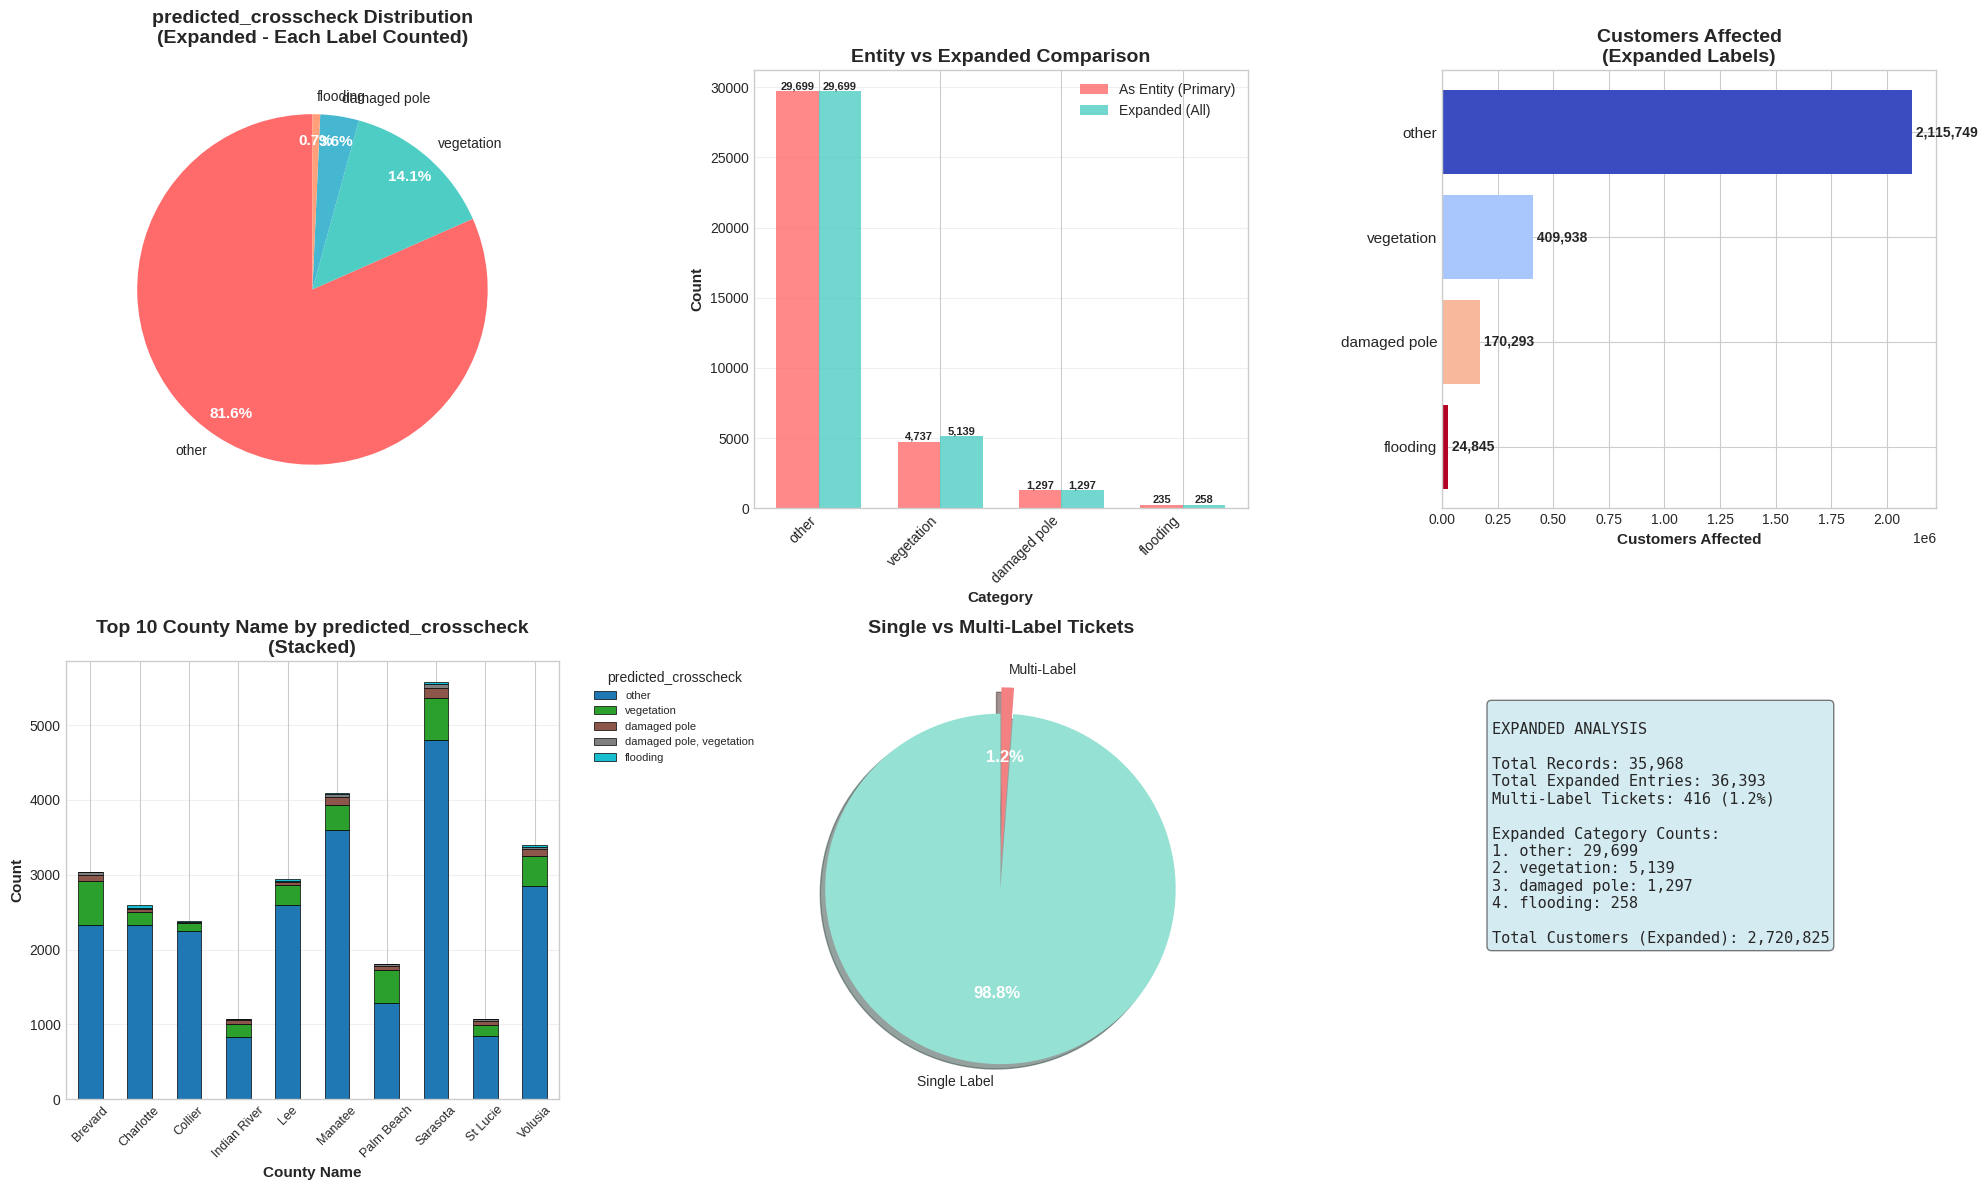

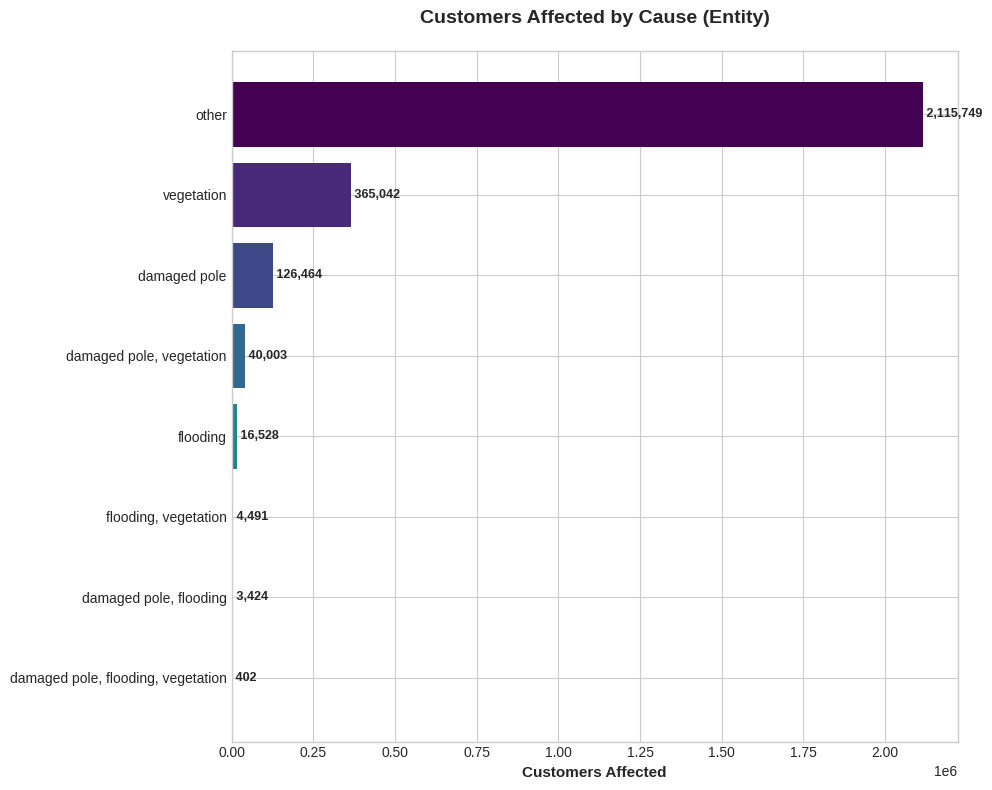

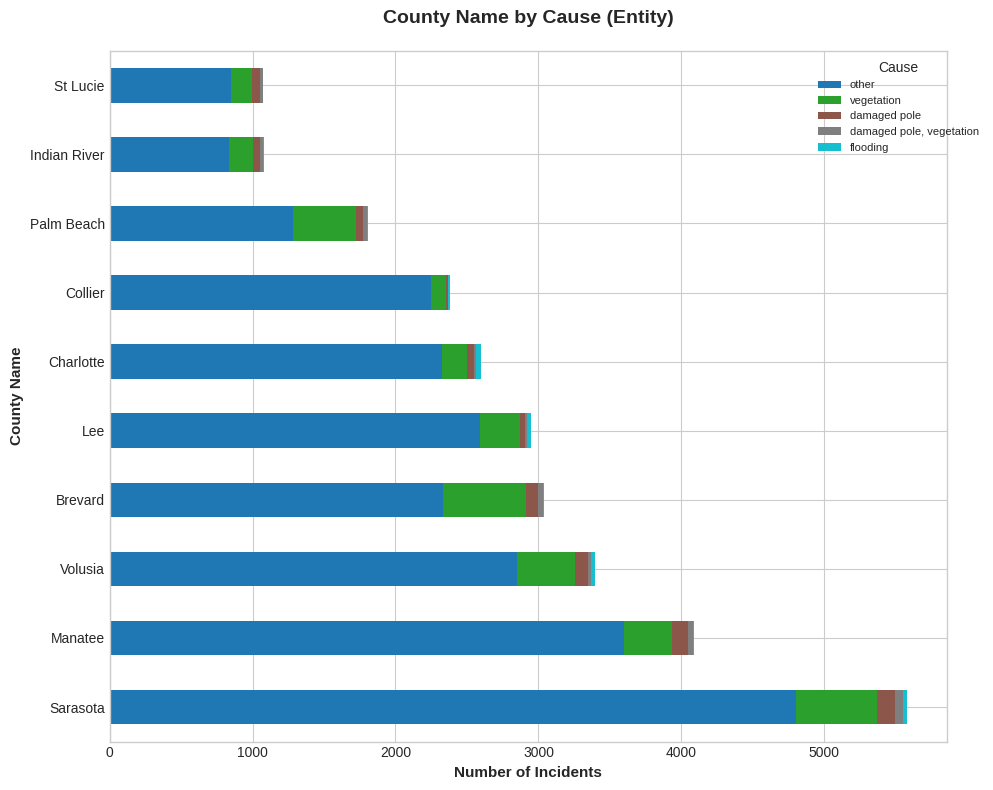

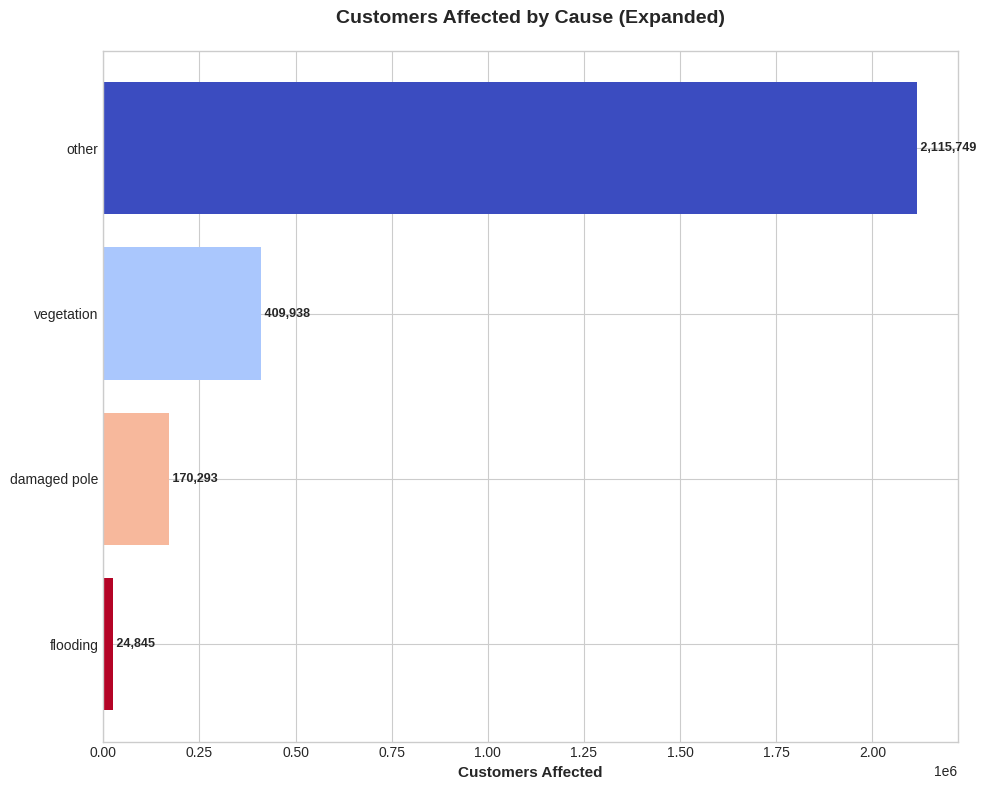

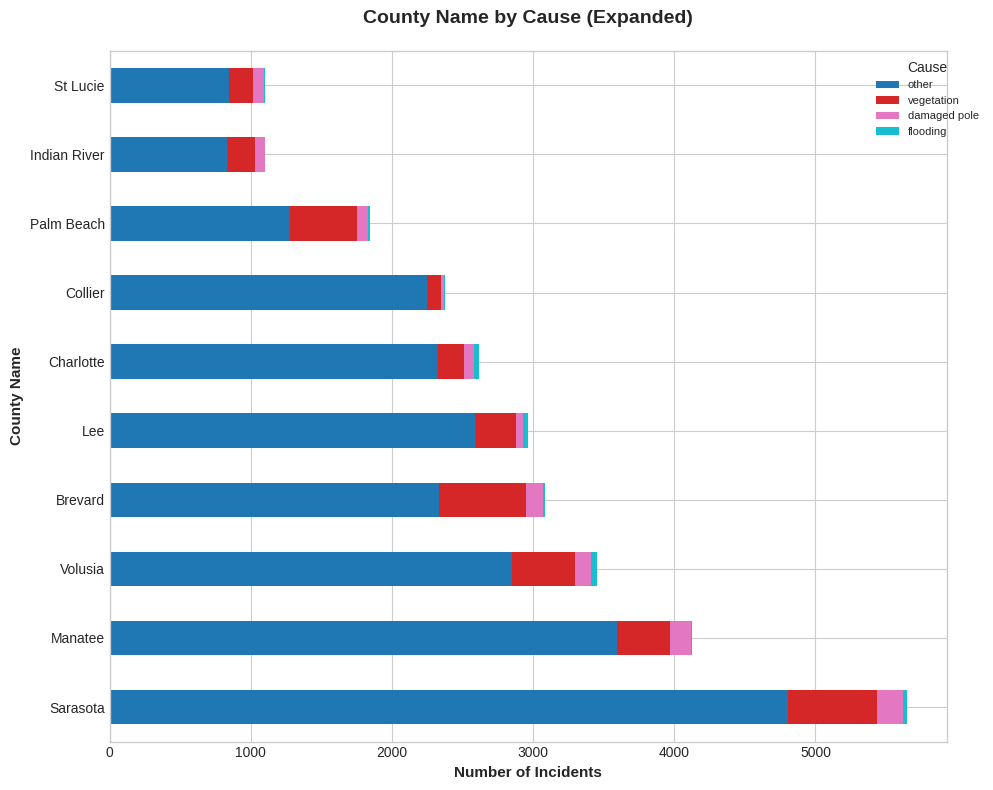

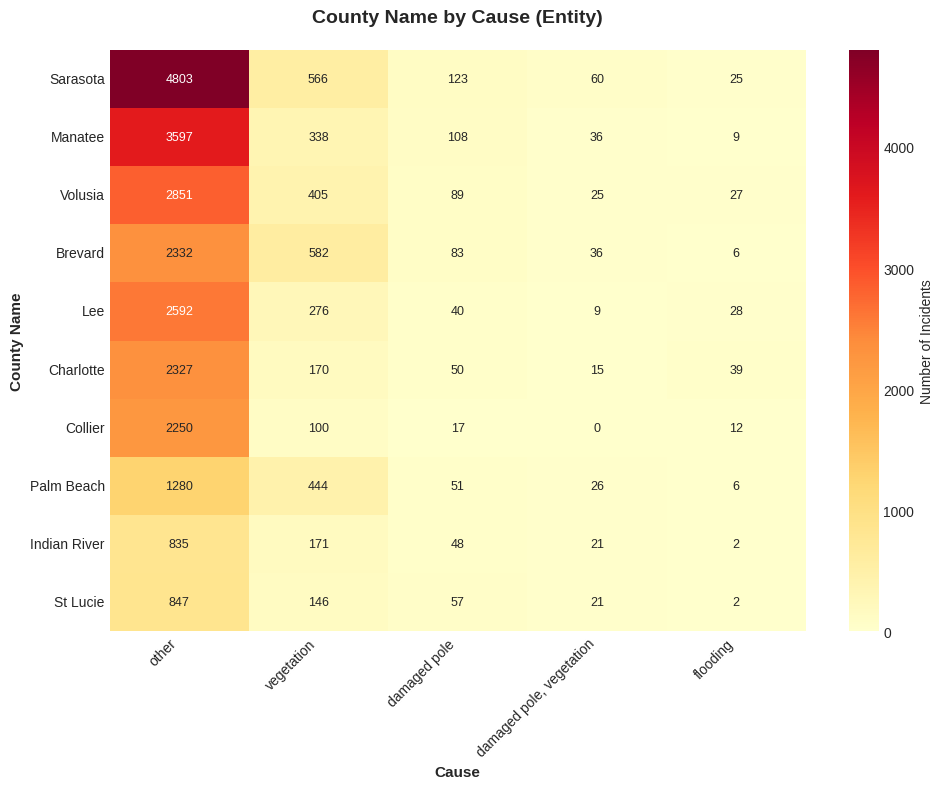

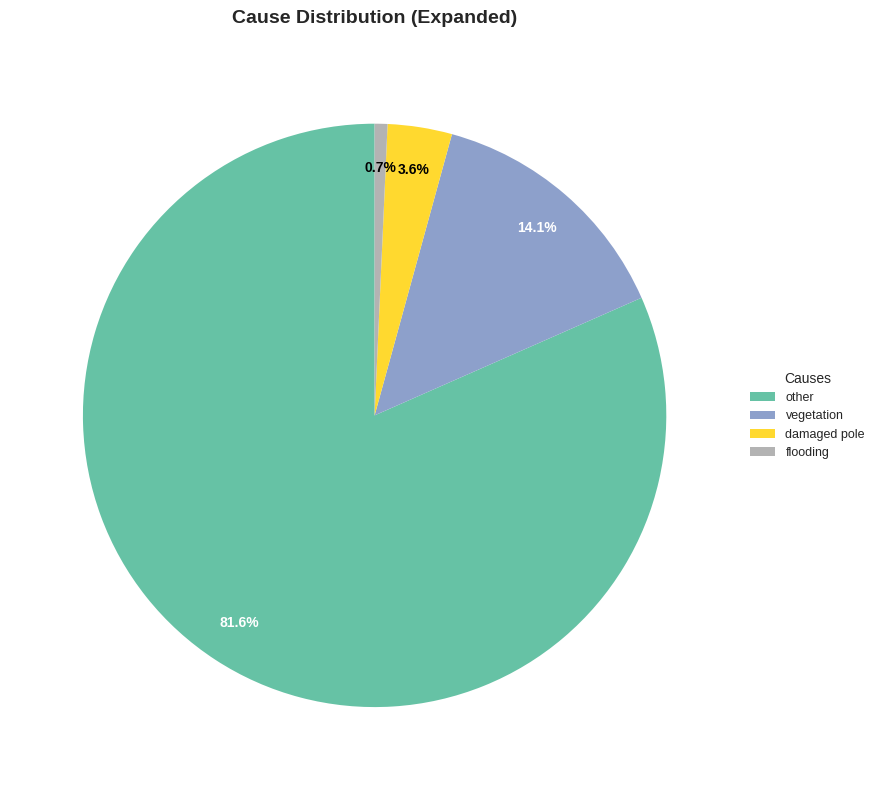

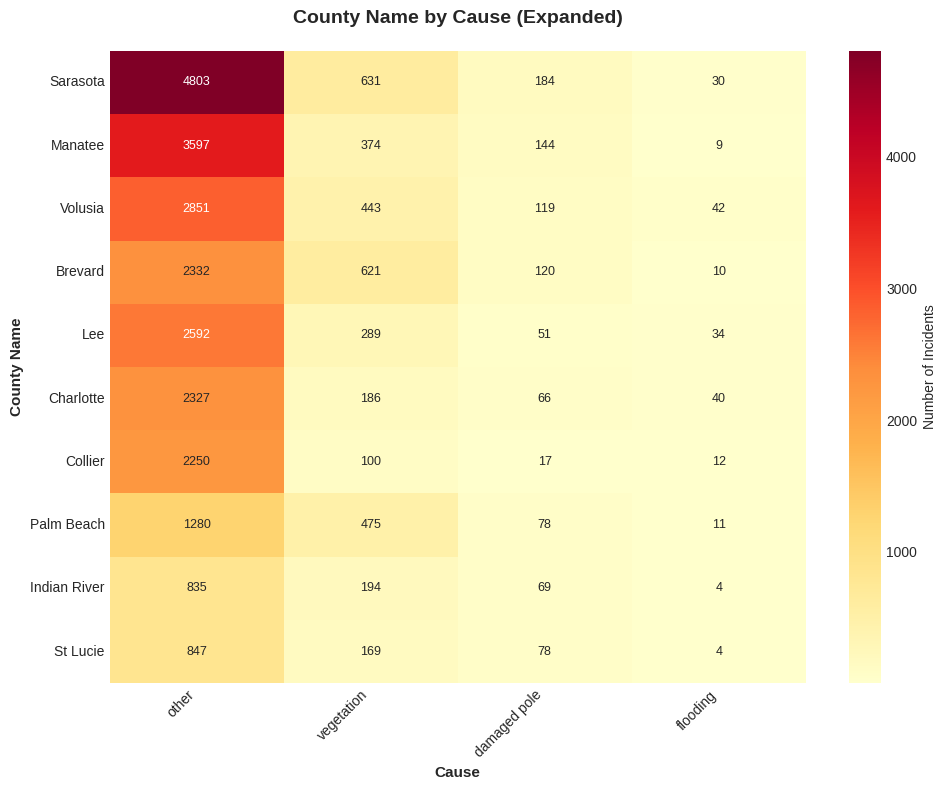

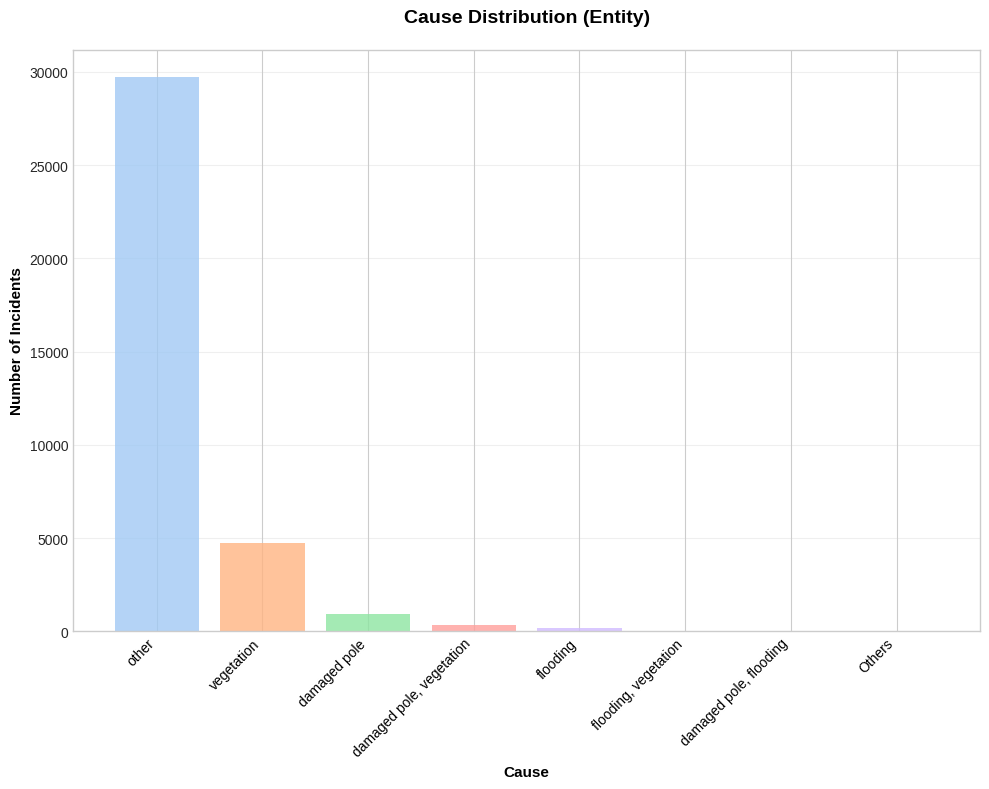

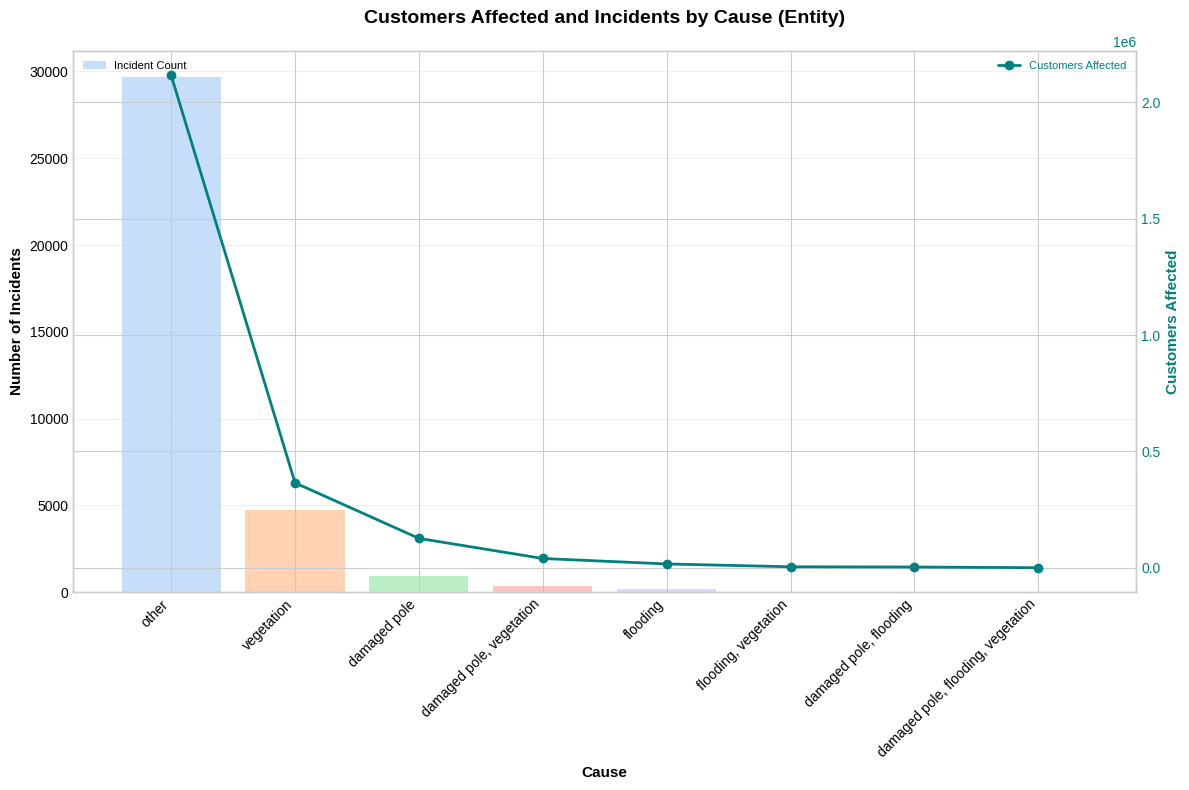

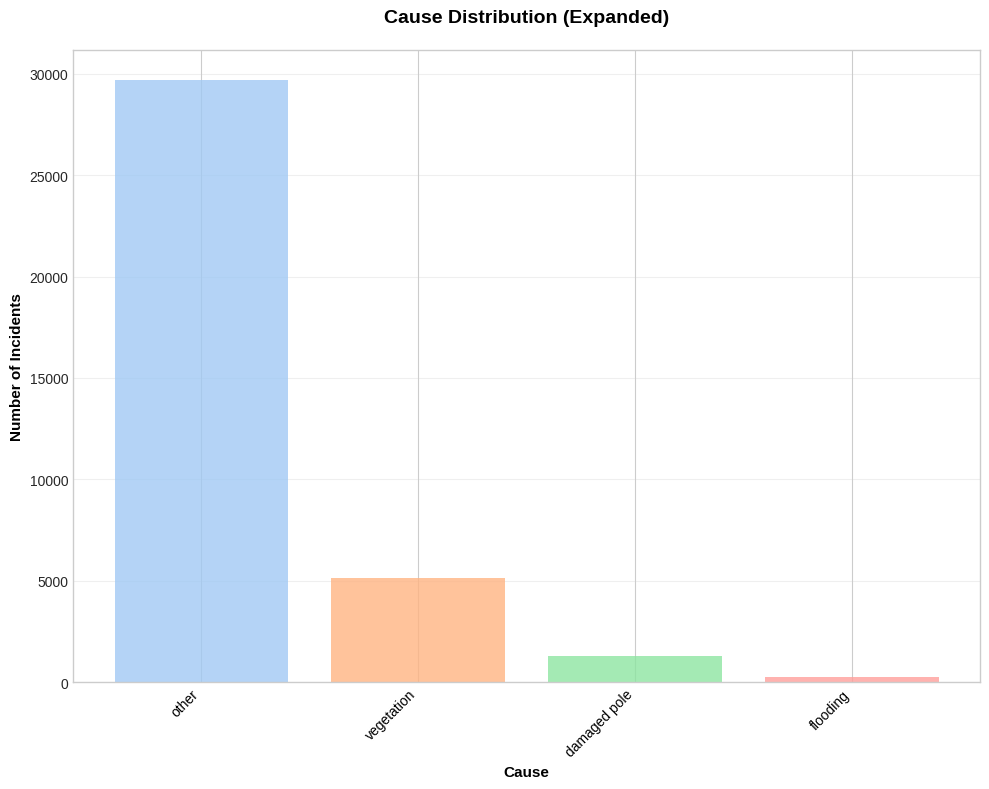

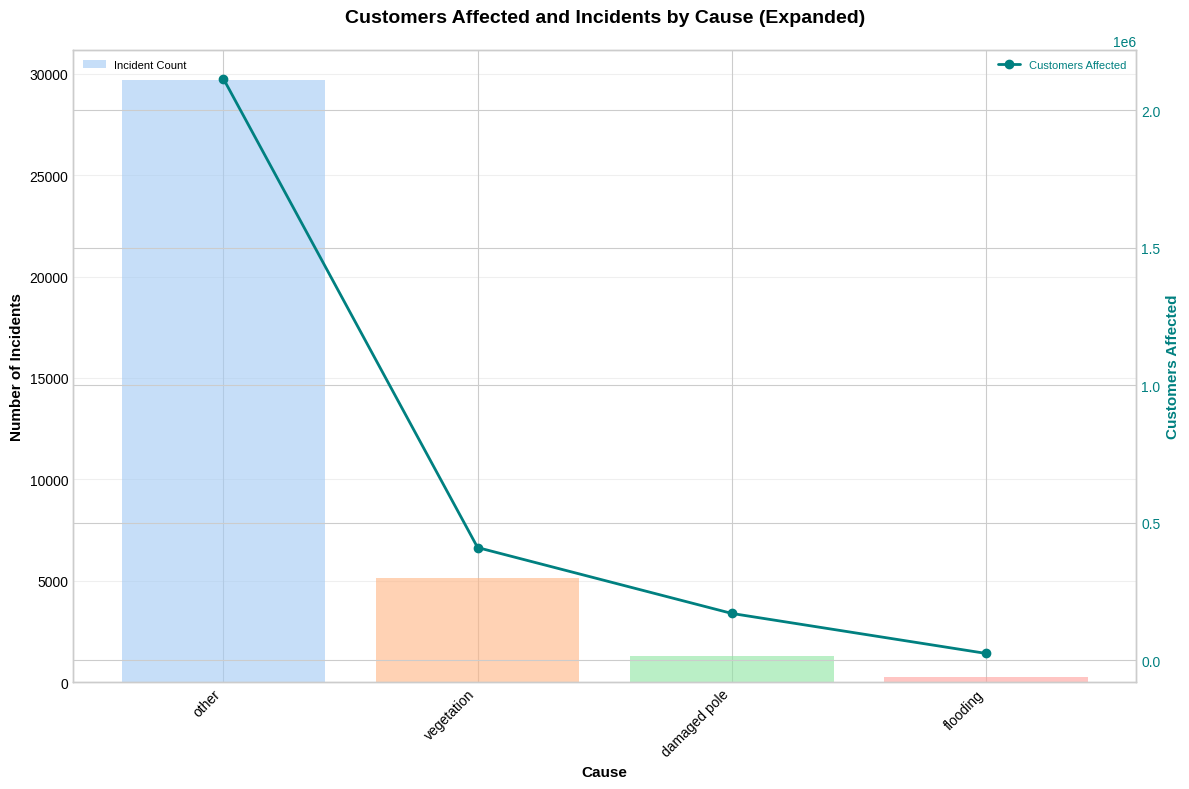

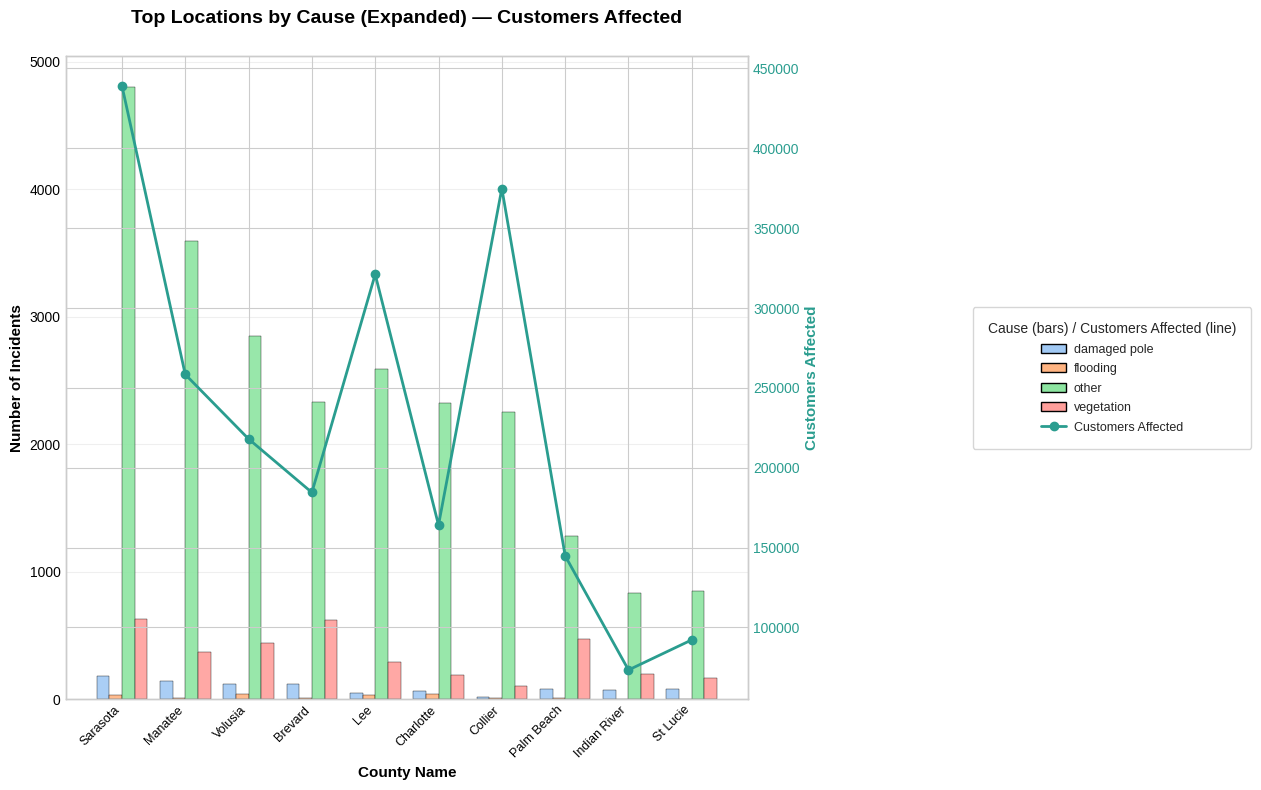


DETAILED predicted_crosscheck ANALYSIS

Total Records: 35,968
Total Expanded Entries: 36,393

--- AS SINGLE ENTITY ---

Top 10 predicted_crosscheck Categories:
predicted_crosscheck
other                                 29699
vegetation                             4737
damaged pole                            919
damaged pole, vegetation                355
flooding                                197
flooding, vegetation                     38
damaged pole, flooding                   14
damaged pole, flooding, vegetation        9
Name: count, dtype: int64

--- EXPANDED (MULTI-LABEL) ---

Expanded predicted_crosscheck Counts:
predicted_crosscheck_expanded
other           29699
vegetation       5139
damaged pole     1297
flooding          258
Name: count, dtype: int64

--- MULTI-LABEL ANALYSIS ---
Single-label tickets: 35,552 (98.8%)
Multi-label tickets: 416 (1.2%)


In [ ]:
#dependency installs again
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import openpyxl
import matplotlib.patches as mpatches

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Load data
df = pd.read_excel(out_file)
print(f"Using this file for visualizations: {out_file}")

# Function to extract individual labels from combined entries
def expand_labels(df, column_name):
    """Expand multi-label entries into separate rows for each label"""
    expanded_rows = []
    for idx, row in df.iterrows():
        labels = str(row[column_name]).split(',')
        labels = [label.strip() for label in labels]
        for label in labels:
            new_row = row.copy()
            new_row[column_name + '_expanded'] = label
            expanded_rows.append(new_row)
    return pd.DataFrame(expanded_rows)

# Create expanded dataset
df_expanded = expand_labels(df, 'predicted_crosscheck')

# Determine location column
location_col = 'County Name' if 'County Name' in df.columns and df['County Name'].notna().sum() > 0 else 'Franchise Name'

# ============================================================
# FIGURE 1: predicted_crosscheck ANALYSIS (AS ENTITIES)
# ============================================================
predicted_crosscheck_counts = df['predicted_crosscheck'].value_counts()
fig1 = plt.figure(figsize=(20, 12))

# 1. predicted_crosscheck Distribution Pie (Top 8 + Others)
ax1 = plt.subplot(2, 3, 1)
top_n = 7
if len(predicted_crosscheck_counts) > top_n:
    top_categories = predicted_crosscheck_counts.head(top_n)
    other_count = predicted_crosscheck_counts.iloc[top_n:].sum()
    plot_data = pd.concat([top_categories, pd.Series({'others': other_count})])
else:
    plot_data = predicted_crosscheck_counts

colors = plt.cm.Set3(np.linspace(0, 1, len(plot_data)))
wedges, texts, autotexts = ax1.pie(plot_data, labels=None, autopct='%1.1f%%',
                                     colors=colors, startangle=90, pctdistance=0.85)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_weight('bold')
ax1.set_title('predicted_crosscheck Distribution\n(As Single Entity)', fontsize=14, fontweight='bold', pad=20)
ax1.legend(plot_data.index, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)

# 2. Top 10 predicted_crosscheck Categories (Horizontal Bar)
ax2 = plt.subplot(2, 3, 2)
top10_predicted_crosscheck = predicted_crosscheck_counts.head(10)
bars = ax2.barh(range(len(top10_predicted_crosscheck)), top10_predicted_crosscheck.values, color=plt.cm.Spectral(np.linspace(0, 1, 10)))
ax2.set_yticks(range(len(top10_predicted_crosscheck)))
ax2.set_yticklabels(top10_predicted_crosscheck.index, fontsize=10)
ax2.set_xlabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('Top 10 predicted_crosscheck Categories\n(As Single Entity)', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, top10_predicted_crosscheck.values)):
    ax2.text(val, i, f' {val:,}', va='center', fontweight='bold', fontsize=9)

# 3. Customers Affected by Top predicted_crosscheck Categories
ax3 = plt.subplot(2, 3, 3)
cust_by_predicted_crosscheck = df.groupby('predicted_crosscheck')['CI'].sum().sort_values(ascending=False).head(10)
bars = ax3.barh(range(len(cust_by_predicted_crosscheck)), cust_by_predicted_crosscheck.values,
                color=plt.cm.viridis(np.linspace(0, 1, 10)))
ax3.set_yticks(range(len(cust_by_predicted_crosscheck)))
ax3.set_yticklabels(cust_by_predicted_crosscheck.index, fontsize=10)
ax3.set_xlabel('Customers Affected', fontsize=11, fontweight='bold')
ax3.set_title('Top 10: Customers Affected\n(As Single Entity)', fontsize=14, fontweight='bold')
ax3.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, cust_by_predicted_crosscheck.values)):
    ax3.text(val, i, f' {val:,.0f}', va='center', fontweight='bold', fontsize=9)

# 5. Heatmap: Top 10 Locations vs Top 5 predicted_crosscheck
ax5 = plt.subplot(2, 3, 5)
top_locations = df[location_col].value_counts().head(10).index
top_predicted_crosschecks = df['predicted_crosscheck'].value_counts().head(5).index
pivot_data = df[df[location_col].isin(top_locations) & df['predicted_crosscheck'].isin(top_predicted_crosschecks)].pivot_table(
    values='CI', index=location_col, columns='predicted_crosscheck', aggfunc='sum', fill_value=0)
sns.heatmap(pivot_data, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=1, linecolor='gray', ax=ax5, cbar_kws={'label': 'Customers'})
ax5.set_title(f'Customers Affected Heatmap\nTop 10 {location_col} vs Top 5 predicted_crosscheck',
              fontsize=12, fontweight='bold')
ax5.set_xlabel('predicted_crosscheck', fontsize=10, fontweight='bold')
ax5.set_ylabel(location_col, fontsize=10, fontweight='bold')
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)
plt.setp(ax5.yaxis.get_majorticklabels(), fontsize=9)

# 6. Distribution Stats
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
stats_text = f"""
SUMMARY STATISTICS (As Entity)

Total Records: {len(df):,}

Top 5 predicted_crosscheck Categories:
"""
for idx, (cat, count) in enumerate(predicted_crosscheck_counts.head(5).items(), 1):
    stats_text += f"{idx}. {cat}: {count:,}\n"

stats_text += f"\nTotal Customers Affected: {df['CI'].sum():,.0f}"
stats_text += f"\nAverage per Record: {df['CI'].mean():.1f}"
stats_text += f"\nMedian per Record: {df['CI'].median():.1f}"

ax6.text(0.1, 0.9, stats_text, transform=ax6.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('predicted_crosscheck_analysis_entity.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 2: predicted_crosscheck ANALYSIS (EXPANDED/MULTI-LABEL)
# ============================================================
fig2 = plt.figure(figsize=(20, 12))

expanded_counts = df_expanded['predicted_crosscheck_expanded'].value_counts()

# 1. Expanded predicted_crosscheck Distribution
ax1 = plt.subplot(2, 3, 1)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#F7DC6F']
wedges, texts, autotexts = ax1.pie(expanded_counts, labels=expanded_counts.index,
                                     autopct='%1.1f%%', colors=colors, startangle=90,
                                     pctdistance=0.85)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_weight('bold')
ax1.set_title('predicted_crosscheck Distribution\n(Expanded - Each Label Counted)', fontsize=14, fontweight='bold', pad=20)

# 2. Expanded vs Entity Comparison
ax2 = plt.subplot(2, 3, 2)
entity_main = df['predicted_crosscheck'].str.split(',').str[0].str.strip().value_counts().head(6)
expanded_main = df_expanded['predicted_crosscheck_expanded'].value_counts().head(6)
x = np.arange(len(entity_main))
width = 0.35
bars1 = ax2.bar(x - width/2, entity_main.values, width, label='As Entity (Primary)', color='#FF6B6B', alpha=0.8)
bars2 = ax2.bar(x + width/2, expanded_main.values, width, label='Expanded (All)', color='#4ECDC4', alpha=0.8)
ax2.set_xlabel('Category', fontsize=11, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('Entity vs Expanded Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(entity_main.index, rotation=45, ha='right', fontsize=10)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height):,}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 3. Customers Affected (Expanded)
ax3 = plt.subplot(2, 3, 3)
cust_expanded = df_expanded.groupby('predicted_crosscheck_expanded')['CI'].sum().sort_values(ascending=False)
bars = ax3.barh(range(len(cust_expanded)), cust_expanded.values,
                color=plt.cm.coolwarm(np.linspace(0, 1, len(cust_expanded))))
ax3.set_yticks(range(len(cust_expanded)))
ax3.set_yticklabels(cust_expanded.index, fontsize=11)
ax3.set_xlabel('Customers Affected', fontsize=11, fontweight='bold')
ax3.set_title('Customers Affected\n(Expanded Labels)', fontsize=14, fontweight='bold')
ax3.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, cust_expanded.values)):
    ax3.text(val, i, f' {val:,.0f}', va='center', fontweight='bold', fontsize=10)

# 4. Stacked Area Chart for Top Locations
ax4 = plt.subplot(2, 3, 4)
top10_locs = df[location_col].value_counts().head(10).index
location_predicted_crosscheck = df[df[location_col].isin(top10_locs)].groupby([location_col, 'predicted_crosscheck']).size().unstack(fill_value=0)
top_predicted_crosscheck_cols = df['predicted_crosscheck'].value_counts().head(5).index
location_predicted_crosscheck_top = location_predicted_crosscheck[top_predicted_crosscheck_cols] if all(col in location_predicted_crosscheck.columns for col in top_predicted_crosscheck_cols) else location_predicted_crosscheck
location_predicted_crosscheck_top.plot(kind='bar', stacked=True, ax=ax4,
                              colormap='tab10', edgecolor='black', linewidth=0.5)
ax4.set_title(f'Top 10 {location_col} by predicted_crosscheck\n(Stacked)', fontsize=14, fontweight='bold')
ax4.set_xlabel(location_col, fontsize=11, fontweight='bold')
ax4.set_ylabel('Count', fontsize=11, fontweight='bold')
ax4.legend(title='predicted_crosscheck', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax4.tick_params(axis='x', rotation=45, labelsize=9)
ax4.grid(axis='y', alpha=0.3)

# 5. Multi-label Analysis
ax5 = plt.subplot(2, 3, 5)
multi_label_count = df['predicted_crosscheck'].str.contains(',').sum()
single_label_count = len(df) - multi_label_count
labels = ['Single Label', 'Multi-Label']
sizes = [single_label_count, multi_label_count]
colors = ['#95E1D3', '#F38181']
explode = (0.05, 0.1)
wedges, texts, autotexts = ax5.pie(sizes, labels=labels, autopct='%1.1f%%',
                                     colors=colors, explode=explode, shadow=True, startangle=90)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')
ax5.set_title('Single vs Multi-Label Tickets', fontsize=14, fontweight='bold', pad=20)

# 6. Expanded Statistics
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
stats_text = f"""
EXPANDED ANALYSIS

Total Records: {len(df):,}
Total Expanded Entries: {len(df_expanded):,}
Multi-Label Tickets: {multi_label_count:,} ({multi_label_count/len(df)*100:.1f}%)

Expanded Category Counts:
"""
for idx, (cat, count) in enumerate(expanded_counts.items(), 1):
    stats_text += f"{idx}. {cat}: {count:,}\n"

stats_text += f"\nTotal Customers (Expanded): {df_expanded['CI'].sum():,.0f}"

ax6.text(0.1, 0.9, stats_text, transform=ax6.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.savefig('predicted_crosscheck_analysis_expanded.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Customers Affected vs Cause (Entity)
fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111)
cust_by_cause = df.groupby('predicted_crosscheck')['CI'].sum().sort_values(ascending=False).head(10)
bars = ax2.barh(range(len(cust_by_cause)), cust_by_cause.values,
                color=plt.cm.viridis(np.linspace(0, 1, 10)))
ax2.set_yticks(range(len(cust_by_cause)))
ax2.set_yticklabels(cust_by_cause.index, fontsize=10)
ax2.set_xlabel('Customers Affected', fontsize=11, fontweight='bold')
ax2.set_title('Customers Affected by Cause (Entity)', fontsize=14, fontweight='bold', pad=20)
ax2.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, cust_by_cause.values)):
    ax2.text(val, i, f' {val:,.0f}', va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('customers_affected_entity.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig2)

# 3. Location vs Cause (Entity)
fig3 = plt.figure(figsize=(10, 8))
ax3 = fig3.add_subplot(111)
pivot_data = df.groupby([location_col, 'predicted_crosscheck']).size().unstack(fill_value=0)
top_locs = df[location_col].value_counts().head(10).index
top_causes = df['predicted_crosscheck'].value_counts().head(5).index
plot_data = pivot_data.loc[top_locs, top_causes]
plot_data.plot(kind='barh', stacked=True, ax=ax3, colormap='tab10')
ax3.set_title(f'{location_col} by Cause (Entity)', fontsize=14, fontweight='bold', pad=20)
ax3.set_xlabel('Number of Incidents', fontsize=11, fontweight='bold')
ax3.set_ylabel(location_col, fontsize=11, fontweight='bold')
ax3.legend(title='Cause', bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout()
plt.savefig('location_vs_cause_entity_stacked.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig3)

# 5. Customers Affected vs Cause (Expanded)
fig5 = plt.figure(figsize=(10, 8))
ax5 = fig5.add_subplot(111)
cust_expanded = df_expanded.groupby('predicted_crosscheck_expanded')['CI'].sum().sort_values(ascending=False)
bars = ax5.barh(range(len(cust_expanded)), cust_expanded.values,
                color=plt.cm.coolwarm(np.linspace(0, 1, len(cust_expanded))))
ax5.set_yticks(range(len(cust_expanded)))
ax5.set_yticklabels(cust_expanded.index, fontsize=10)
ax5.set_xlabel('Customers Affected', fontsize=11, fontweight='bold')
ax5.set_title('Customers Affected by Cause (Expanded)', fontsize=14, fontweight='bold', pad=20)
ax5.invert_yaxis()
for i, (bar, val) in enumerate(zip(bars, cust_expanded.values)):
    ax5.text(val, i, f' {val:,.0f}', va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.savefig('customers_affected_expanded.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig5)

# 6. Location vs Cause (Expanded)
fig6 = plt.figure(figsize=(10, 8))
ax6 = fig6.add_subplot(111)
pivot_data_exp = df_expanded.groupby([location_col, 'predicted_crosscheck_expanded']).size().unstack(fill_value=0)
top_locs = df[location_col].value_counts().head(10).index
top_causes_exp = df_expanded['predicted_crosscheck_expanded'].value_counts().head(5).index
plot_data_exp = pivot_data_exp.loc[top_locs, top_causes_exp]
plot_data_exp.plot(kind='barh', stacked=True, ax=ax6, colormap='tab10')
ax6.set_title(f'{location_col} by Cause (Expanded)', fontsize=14, fontweight='bold', pad=20)
ax6.set_xlabel('Number of Incidents', fontsize=11, fontweight='bold')
ax6.set_ylabel(location_col, fontsize=11, fontweight='bold')
ax6.legend(title='Cause', bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout()
plt.savefig('location_vs_cause_expanded_stacked.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig6)

# 3. Location vs Cause (Entity) - Heatmap version
fig3_heatmap = plt.figure(figsize=(10, 8))
ax3_heatmap = fig3_heatmap.add_subplot(111)
pivot_data = df.groupby([location_col, 'predicted_crosscheck']).size().unstack(fill_value=0)
top_locs = df[location_col].value_counts().head(10).index
top_causes = df['predicted_crosscheck'].value_counts().head(5).index
heatmap_data = pivot_data.loc[top_locs, top_causes]
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax3_heatmap,
            annot_kws={'size': 9}, cbar_kws={'label': 'Number of Incidents'})
ax3_heatmap.set_title(f'{location_col} by Cause (Entity)', fontsize=14, fontweight='bold', pad=20)
ax3_heatmap.set_xlabel('Cause', fontsize=11, fontweight='bold')
ax3_heatmap.set_ylabel(location_col, fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('location_vs_cause_entity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig3_heatmap)

# ============================================================
# EXPANDED GRAPHS
# ============================================================

# 4. Cause Distribution Pie (Expanded)
fig4 = plt.figure(figsize=(10, 8))
ax4 = fig4.add_subplot(111)
expanded_counts = df_expanded['predicted_crosscheck_expanded'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(expanded_counts)))
wedges, texts, autotexts = ax4.pie(expanded_counts, autopct='%1.1f%%', colors=colors, startangle=90,
                                   pctdistance=0.85, textprops={'fontsize': 10, 'weight': 'bold'})
for autotext in autotexts:
    autotext.set_color('white' if float(autotext.get_text().strip('%')) > 5 else 'black')
    autotext.set_fontsize(10)
    autotext.set_weight('bold')

ax4.legend(expanded_counts.index, title='Causes', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)
ax4.set_title('Cause Distribution (Expanded)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('cause_distribution_expanded_pie.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig4)


# 6. Location vs Cause (Expanded) - Heatmap version
fig6_heatmap = plt.figure(figsize=(10, 8))
ax6_heatmap = fig6_heatmap.add_subplot(111)
pivot_data_exp = df_expanded.groupby([location_col, 'predicted_crosscheck_expanded']).size().unstack(fill_value=0)
top_locs = df[location_col].value_counts().head(10).index
top_causes_exp = df_expanded['predicted_crosscheck_expanded'].value_counts().head(5).index
heatmap_data_exp = pivot_data_exp.loc[top_locs, top_causes_exp]
sns.heatmap(heatmap_data_exp, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax6_heatmap,
            annot_kws={'size': 9}, cbar_kws={'label': 'Number of Incidents'})
ax6_heatmap.set_title(f'{location_col} by Cause (Expanded)', fontsize=14, fontweight='bold', pad=20)
ax6_heatmap.set_xlabel('Cause', fontsize=11, fontweight='bold')
ax6_heatmap.set_ylabel(location_col, fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('location_vs_cause_expanded_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig6_heatmap)

# 1. Cause Distribution (Entity) - Bar version
fig1_bar = plt.figure(figsize=(10, 8))
ax1_bar = fig1_bar.add_subplot(111)
cause_counts = df['predicted_crosscheck'].value_counts()
top_n = 7
if len(cause_counts) > top_n:
    top_categories = cause_counts.head(top_n)
    other_count = cause_counts.iloc[top_n:].sum()
    plot_data = pd.concat([top_categories, pd.Series({'Others': other_count})])
else:
    plot_data = cause_counts

ax1_bar.bar(plot_data.index, plot_data.values,
        color=sns.color_palette("pastel", len(plot_data)), alpha=0.8)
ax1_bar.set_xticklabels(plot_data.index, rotation=45, ha='right', fontsize=10, color='black')
ax1_bar.set_ylabel('Number of Incidents', fontsize=11, fontweight='bold', color='black')
ax1_bar.set_xlabel('Cause', fontsize=11, fontweight='bold', color='black')
ax1_bar.set_title('Cause Distribution (Entity)', fontsize=14, fontweight='bold', pad=20, color='black')
ax1_bar.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cause_distribution_entity_bar.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig1_bar)

# 2. Customers Affected and Incidents by Cause (Entity)
fig2_bar_line = plt.figure(figsize=(12, 8))
ax2_bl = fig2_bar_line.add_subplot(111)
cust_by_cause = df.groupby('predicted_crosscheck').agg({'CI': 'sum', 'predicted_crosscheck': 'count'}).rename(columns={'predicted_crosscheck': 'Count'}).sort_values('CI', ascending=False).head(10)
ax2_bl.bar(cust_by_cause.index, cust_by_cause['Count'],
        color=sns.color_palette("pastel", len(cust_by_cause)), alpha=0.6, label='Incident Count')
ax2_bl.set_ylabel('Number of Incidents', fontsize=11, fontweight='bold', color='black')
ax2_bl.tick_params(axis='y', labelcolor='black')

# Overlay line graph for customers affected
ax2_bl_twin = ax2_bl.twinx()
ax2_bl_twin.plot(cust_by_cause.index, cust_by_cause['CI'], color='teal', marker='o', linewidth=2, label='Customers Affected')
ax2_bl_twin.set_ylabel('Customers Affected', fontsize=11, fontweight='bold', color='teal')
ax2_bl_twin.tick_params(axis='y', labelcolor='teal')

ax2_bl.set_xticklabels(cust_by_cause.index, rotation=45, ha='right', fontsize=10, color='black')
ax2_bl.set_xlabel('Cause', fontsize=11, fontweight='bold', color='black')
ax2_bl.set_title('Customers Affected and Incidents by Cause (Entity)', fontsize=14, fontweight='bold', pad=20, color='black')
ax2_bl.grid(True, axis='y', alpha=0.3)
ax2_bl.legend(loc='upper left', fontsize=8, labelcolor='black', facecolor='white')
ax2_bl_twin.legend(loc='upper right', fontsize=8, labelcolor='teal', facecolor='white')
plt.tight_layout()
plt.savefig('ci_and_incidents_entity.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig2_bar_line)

# 4. Cause Distribution (Expanded) - Bar version
fig4_bar = plt.figure(figsize=(10, 8))
ax4_bar = fig4_bar.add_subplot(111)
expanded_counts = df_expanded['predicted_crosscheck_expanded'].value_counts()
ax4_bar.bar(expanded_counts.index, expanded_counts.values,
        color=sns.color_palette("pastel", len(expanded_counts)), alpha=0.8)
ax4_bar.set_xticklabels(expanded_counts.index, rotation=45, ha='right', fontsize=10, color='black')
ax4_bar.set_ylabel('Number of Incidents', fontsize=11, fontweight='bold', color='black')
ax4_bar.set_xlabel('Cause', fontsize=11, fontweight='bold', color='black')
ax4_bar.set_title('Cause Distribution (Expanded)', fontsize=14, fontweight='bold', pad=20, color='black')
ax4_bar.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cause_distribution_expanded_bar.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig4_bar)

# 5. Customers Affected and Incidents by Cause (Expanded)
fig5_bar_line = plt.figure(figsize=(12, 8))
ax5_bl = fig5_bar_line.add_subplot(111)
cust_expanded = df_expanded.groupby('predicted_crosscheck_expanded').agg({'CI': 'sum', 'predicted_crosscheck_expanded': 'count'}).rename(columns={'predicted_crosscheck_expanded': 'Count'}).sort_values('CI', ascending=False)
ax5_bl.bar(cust_expanded.index, cust_expanded['Count'],
        color=sns.color_palette("pastel", len(cust_expanded)), alpha=0.6, label='Incident Count')
ax5_bl.set_ylabel('Number of Incidents', fontsize=11, fontweight='bold', color='black')
ax5_bl.tick_params(axis='y', labelcolor='black')

# Overlay line graph for customers affected
ax5_bl_twin = ax5_bl.twinx()
ax5_bl_twin.plot(cust_expanded.index, cust_expanded['CI'], color='teal', marker='o', linewidth=2, label='Customers Affected')
ax5_bl_twin.set_ylabel('Customers Affected', fontsize=11, fontweight='bold', color='teal')
ax5_bl_twin.tick_params(axis='y', labelcolor='teal')

ax5_bl.set_xticklabels(cust_expanded.index, rotation=45, ha='right', fontsize=10, color='black')
ax5_bl.set_xlabel('Cause', fontsize=11, fontweight='bold', color='black')
ax5_bl.set_title('Customers Affected and Incidents by Cause (Expanded)', fontsize=14, fontweight='bold', pad=20, color='black')
ax5_bl.grid(True, axis='y', alpha=0.3)
ax5_bl.legend(loc='upper left', fontsize=8, labelcolor='black', facecolor='white')
ax5_bl_twin.legend(loc='upper right', fontsize=8, labelcolor='teal', facecolor='white')
plt.tight_layout()
plt.savefig('ci_and_incidents_expanded.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig5_bar_line)

# Set style for last figure
sns.set_palette("pastel")

# Define pastel color mapping for causes (explicit pastel shades)
cause_colors = {
    'Flooding': '#8FBDE8',      # pastel blue
    'Vegetation': '#A7DCA5',    # pastel green
    'Damaged Pole': '#F7A5A5',  # pastel coral/red
    'Other': '#D3D3D3'          # light gray
}

# 6. Location vs Cause (Expanded) - Grouped bar + line version
fig6_grouped = plt.figure(figsize=(14, 8))
ax6_grouped = fig6_grouped.add_subplot(111)

# Prepare data
pivot_data_exp = df_expanded.groupby([location_col, 'predicted_crosscheck_expanded']).agg({
    'CI': 'sum',
    'predicted_crosscheck_expanded': 'size'
}).rename(columns={'predicted_crosscheck_expanded': 'Count'}).reset_index()

top_locs = df[location_col].value_counts().head(10).index
bar_data = pivot_data_exp[pivot_data_exp[location_col].isin(top_locs)]

# Get unique causes from the predicted_crosscheck_expanded column
unique_causes = sorted(bar_data['predicted_crosscheck_expanded'].unique())  # Sort for consistent order

# Build a color map: prefer user-specified pastel cause_colors, else use seaborn pastel palette
default_colors = sns.color_palette('pastel', n_colors=max(3, len(unique_causes)))
color_map = {}
for i, cause in enumerate(unique_causes):
    key = cause.strip()
    # seaborn returns RGB tuples accepted by matplotlib; fallback to pastel palette
    color_map[cause] = cause_colors.get(key, default_colors[i % len(default_colors)])

# Set up bar positions
bar_width = 0.2
bar_positions = np.arange(len(top_locs))

# Plot bars for each cause and ensure we don't create duplicate legend labels
plotted_causes = set()
for idx, cause in enumerate(unique_causes):
    cause_data = bar_data[bar_data['predicted_crosscheck_expanded'] == cause]
    county_counts = {row[location_col]: row['Count'] for _, row in cause_data.iterrows()}
    counts = [county_counts.get(loc, 0) for loc in top_locs]
    color = color_map[cause]
    label = cause if cause not in plotted_causes else None
    ax6_grouped.bar(bar_positions + idx * bar_width, counts, bar_width,
            color=color, alpha=0.9, label=label, edgecolor='black', linewidth=0.3)
    plotted_causes.add(cause)

# Overlay line graph for customers affected and capture its handle
cust_affected = bar_data.groupby(location_col)['CI'].sum().reindex(top_locs).fillna(0)
ax6_grouped_twin = ax6_grouped.twinx()
line_handle, = ax6_grouped_twin.plot(bar_positions + bar_width * (len(unique_causes) - 1) / 2, cust_affected,
              color='#2A9D8F', marker='o', linewidth=2, label='Customers Affected')  # teal-ish pastel line
ax6_grouped_twin.set_ylabel('Customers Affected', fontsize=11, fontweight='bold', color='#2A9D8F')
ax6_grouped_twin.tick_params(axis='y', labelcolor='#2A9D8F')

# Customize axes and title (clearer title)
ax6_grouped.set_ylabel('Number of Incidents', fontsize=11, fontweight='bold', color='black')
ax6_grouped.tick_params(axis='y', labelcolor='black')
ax6_grouped.set_xticks(bar_positions + bar_width * (len(unique_causes) - 1) / 2)
ax6_grouped.set_xticklabels(top_locs, rotation=45, ha='right', fontsize=9, color='black')
ax6_grouped.set_xlabel(location_col, fontsize=11, fontweight='bold', color='black')
ax6_grouped.set_title(f'Top Locations by Cause (Expanded) — Customers Affected', fontsize=14, fontweight='bold', pad=24, color='black')
ax6_grouped.grid(True, axis='y', alpha=0.3)

# Build legend: colored patches for causes + the customers-affected line
cause_patches = [mpatches.Patch(facecolor=color_map[c], edgecolor='black', label=c) for c in unique_causes]
legend_handles = cause_patches + [line_handle]
ax6_grouped.legend(handles=legend_handles,
           title='Cause (bars) / Customers Affected (line)',
           loc='center left',
           bbox_to_anchor=(1.32, 0.5),  # move legend further right for padding
           fontsize=9,
           title_fontsize=10,
           frameon=True,
           borderpad=1.2,
           labelspacing=0.6,
           handletextpad=0.6)

plt.tight_layout()
plt.savefig('location_vs_cause_expanded_grouped.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig6_grouped)

# Print detailed summary
print("\n" + "="*80)
print("DETAILED predicted_crosscheck ANALYSIS")
print("="*80)
print(f"\nTotal Records: {len(df):,}")
print(f"Total Expanded Entries: {len(df_expanded):,}")
print(f"\n--- AS SINGLE ENTITY ---")
print("\nTop 10 predicted_crosscheck Categories:")
print(predicted_crosscheck_counts.head(10))
print(f"\n--- EXPANDED (MULTI-LABEL) ---")
print("\nExpanded predicted_crosscheck Counts:")
print(expanded_counts)
print(f"\n--- MULTI-LABEL ANALYSIS ---")
multi_label_count = df['predicted_crosscheck'].str.contains(',').sum()
single_label_count = len(df) - multi_label_count
print(f"Single-label tickets: {single_label_count:,} ({single_label_count/len(df)*100:.1f}%)")
print(f"Multi-label tickets: {multi_label_count:,} ({multi_label_count/len(df)*100:.1f}%)")
print("="*80)